# Predicting Neighborhood-Level Influenza Outbreaks in Boston Using Graph Neural Networks (Post-COVID Variant: 2022-07-01+)

This notebook implements a **Spatio-Temporal Graph Neural Network (ST-GNN)** using **PyTorch** and **PyTorch Geometric** to predict influenza case rates at the neighborhood level in Boston.

**Pipeline:**
1. Load & preprocess real BPHC, MDPH, and City of Boston data from `../Data/`
2. Construct a geographic adjacency graph over 14 Boston neighborhoods + 1 background anchor node
3. Train a GCN-based model with global covariate fusion
4. Evaluate and visualize predictions

**Data folder structure expected:**
```
Data/
├── BPHC/
│   ├── BPHC Dashboard Influenza Demographics.csv
│   ├── BPHC Dashboard Influenza ED Visits-type 1.csv
│   ├── BPHC Dashboard Influenza ED Visits-type 2.csv
│   ├── BPHC Dashboard Influenza Neighborhood.csv
│   └── BPHC Dashboard Influenza Wastewater.csv
├── Mass/
│   ├── Mass Dashboard Vaccination Data 2023-2024.xlsx
│   ├── Mass Dashboard Vaccination Data 2024-2025.xlsx
│   └── Mass Dashboard Vaccination Data 2025-2026.xlsx
└── CityOfBoston/
    ├── Age_in_Boston.csv
    ├── Children_by_Age_in_Boston.csv
    ├── Commute_Mode_in_Boston.csv
    ├── Housing_Tenure_in_Boston.csv
    ├── Housing_Units_in_Boston.csv
    ├── Population_in_Boston.csv
    ├── Poverty_Status_in_Boston.csv
    ├── Race_and_Ethnicity_in_Boston.csv
    └── Vehicles_Available_in_Boston.csv
```


## 0. Setup & Imports

In [1]:
# --- Uncomment and run once to install dependencies ---
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#!pip install torch-geometric
#!pip install openpyxl

from codecarbon import OfflineEmissionsTracker
tracker = OfflineEmissionsTracker(country_iso_code="USA", log_level="error", project_name="Flu Prediction with GNNs - Boston Neighborhoods")
tracker.start()

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

np.random.seed(42)
torch.manual_seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

# --- Paths ---
DATA_DIR = os.path.join('..', 'Data')
BPHC_DIR = os.path.join(DATA_DIR, 'BPHC Flu Data')
MASS_DIR = os.path.join(DATA_DIR, 'Mass Flu Vaccination Data')
CITY_DIR = os.path.join(DATA_DIR, 'Neighborhood Data')

for d in [BPHC_DIR, MASS_DIR, CITY_DIR]:
    assert os.path.isdir(d), f"Missing directory: {d}"
print("All data directories found.")

[codecarbon INFO @ 00:33:58] offline tracker init


[codecarbon WARNING @ 00:33:58] Multiple instances of codecarbon are allowed to run at the same time.


Using device: cpu
All data directories found.


## 0b. Feature Toggles & Time Filter

Flip the booleans below to include/exclude features from the model. `EXCLUDE_COVID` removes weeks in `[COVID_START, COVID_END]` from all aligned time series before training.


In [2]:
# ============================================================
# FEATURE TOGGLES — flip these to include/exclude features.
# Flu lookback is always ON (autoregressive signal).
# ============================================================

# Per-neighborhood feature groups
USE_WASTEWATER    = False  # 4 wastewater lag features per node
USE_WEATHER       = True   # 6 weather features per node
USE_DEMOGRAPHICS  = True   # 8 static demographic features per node

# Global (city-wide) covariates — each independently toggleable
USE_VACCINATION   = True
USE_ILI_COUNT     = True
USE_ED_COUNT      = True
USE_ILI_ED_PERC   = True
USE_FLU_CASES     = True
USE_MONTHLY_CASES = True

# ============================================================
# TIME FILTERS — applied to flu_pivot before alignment.
# Samples whose 4-week lookback window crosses any filter boundary
# are dropped (no fake autoregressive jumps across deleted weeks).
# ============================================================
EXCLUDE_COVID = False        # drop weeks in [COVID_START, COVID_END]
COVID_START   = '2020-03-01'
COVID_END     = '2022-06-30'

MIN_DATE      = '2022-07-01'         # e.g. '2022-07-01' to use only post-COVID data
MAX_DATE      = None         # e.g. '2024-12-31' to cap the upper end

print(f"EXCLUDE_COVID = {EXCLUDE_COVID}")
print(f"MIN_DATE      = {MIN_DATE}")
print(f"MAX_DATE      = {MAX_DATE}")
print("Feature toggles:")
for name, val in [
    ('USE_WASTEWATER', USE_WASTEWATER), ('USE_WEATHER', USE_WEATHER),
    ('USE_DEMOGRAPHICS', USE_DEMOGRAPHICS), ('USE_VACCINATION', USE_VACCINATION),
    ('USE_ILI_COUNT', USE_ILI_COUNT), ('USE_ED_COUNT', USE_ED_COUNT),
    ('USE_ILI_ED_PERC', USE_ILI_ED_PERC), ('USE_FLU_CASES', USE_FLU_CASES),
    ('USE_MONTHLY_CASES', USE_MONTHLY_CASES),
]:
    print(f"  {name:20s} = {val}")

# ============================================================
# TEST WINDOW — fixed evaluation period (2025-26 flu season).
# Test set = samples whose target week falls in [TEST_START_DATE, TEST_END_DATE].
# Val set  = chronologically last 15% of remaining samples (just before test).
# Train    = everything else.
# ============================================================
TEST_START_DATE = '2025-10-01'
TEST_END_DATE   = '2026-05-31'
print(f"TEST window  = {TEST_START_DATE} -> {TEST_END_DATE}")


EXCLUDE_COVID = False
MIN_DATE      = 2022-07-01
MAX_DATE      = None
Feature toggles:
  USE_WASTEWATER       = False
  USE_WEATHER          = True
  USE_DEMOGRAPHICS     = True
  USE_VACCINATION      = True
  USE_ILI_COUNT        = True
  USE_ED_COUNT         = True
  USE_ILI_ED_PERC      = True
  USE_FLU_CASES        = True
  USE_MONTHLY_CASES    = True
TEST window  = 2025-10-01 -> 2026-05-31


## 1. Neighborhood Definitions & Mappings

The 14 model neighborhoods and how each data source maps to them.


In [3]:
# --- 14 canonical neighborhoods used as graph nodes ---
NEIGHBORHOODS = [
    'Allston/Brighton',
    'Back Bay/Beacon Hill/Downtown/North End/West End',
    'Charlestown',
    'Dorchester',
    'East Boston',
    'Fenway',
    'Hyde Park',
    'Jamaica Plain',
    'Mattapan',
    'Roslindale',
    'Roxbury',
    'South Boston',
    'South End',
    'West Roxbury',
]
SHORT_NAMES = [
    'Allston', 'BackBay+', 'Charles.', 'Dorchest.', 'E.Boston',
    'Fenway', 'HydePark', 'JP', 'Mattapan', 'Roslind.',
    'Roxbury', 'S.Boston', 'S.End', 'W.Roxbury',
]
N_NEIGH = len(NEIGHBORHOODS)
# --- Surrounding-area anchor nodes (feature-less; smooth boundary neighborhoods) ---
BG_NODES = [
    'Cambridge/Somerville',
    'Charles River',
    'Chelsea/Revere/Winthrop',
    'Boston Harbor',
    'South Suburbs (Milton/Quincy)',
    'West Suburbs (Newton/Dedham)',
    'Brookline',
]
BG_SHORT = ['Camb/Somer', 'CharlesR', 'Chelsea+', 'Harbor', 'S.Suburbs', 'W.Suburbs', 'Brookline']
ALL_NODES    = SHORT_NAMES + BG_SHORT
N_BG         = len(BG_SHORT)
N_NODES      = N_NEIGH + N_BG
BG_IDX_LIST  = list(range(N_NEIGH, N_NODES))
BG_SHORT_SET = set(BG_SHORT)

# --- Mapping: BPHC Neighborhood CSV values -> canonical index ---
# BPHC has two Dorchester rows that we average
BPHC_TO_IDX = {
    'Allston/Brighton': 0,
    'Back Bay, Beacon Hill, Downtown, North End, West End': 1,
    'Charlestown': 2,
    'Dorchester (02121, 02125)': 3,   # averaged with next
    'Dorchester (02122, 02124)': 3,   # averaged with above
    'East Boston': 4,
    'Fenway': 5,
    'Hyde Park': 6,
    'Jamaica Plain': 7,
    'Mattapan': 8,
    'Roslindale': 9,
    'Roxbury': 10,
    'South Boston': 11,
    'South End': 12,
    'West Roxbury': 13,
}

# --- Mapping: Wastewater neighborhood -> canonical index ---
# Some wastewater zones cover multiple model neighborhoods
WASTEWATER_TO_IDX = {
    'Allston/Brighton': [0],
    'Back Bay': [1, 5, 11, 12],  # Back Bay zone covers BackBay+, Fenway, S.Boston, S.End
    'Charlestown': [2],
    'Dorchester': [3],
    'East Boston': [4],
    'Hyde Park': [6],
    'Jamaica Plain': [7],
    'Mattapan': [8],
    'Roslindale/West Roxbury': [9, 13],
    'Roxbury': [10],
}

# --- Mapping: City of Boston GEOIDs -> canonical index ---
# Multiple sub-neighborhoods aggregate into one model node
GEOID_TO_IDX = {
    'Allston': 0, 'Brighton': 0,
    'Back Bay': 1, 'Beacon Hill': 1, 'Downtown': 1, 'North End': 1, 'West End': 1,
    'Charlestown': 2,
    'Dorchester': 3,
    'East Boston': 4,
    'Fenway': 5, 'Longwood': 5,
    'Hyde Park': 6,
    'Jamaica Plain': 7,
    'Mattapan': 8,
    'Roslindale': 9,
    'Mission Hill': 10, 'Roxbury': 10,
    'South Boston': 11, 'South Boston Waterfront': 11,
    'Chinatown': 12, 'South End': 12,
    'West Roxbury': 13,
}

# Approximate geographic centers (lon, lat) for plotting
COORDS = {
    'Allston':    (-71.1310, 42.3535),
    'BackBay+':   (-71.0680, 42.3550),
    'Charles.':   (-71.0600, 42.3780),
    'Dorchest.':  (-71.0560, 42.3000),
    'E.Boston':   (-71.0200, 42.3750),
    'Fenway':     (-71.1000, 42.3430),
    'HydePark':   (-71.1250, 42.2560),
    'JP':         (-71.1150, 42.3100),
    'Mattapan':   (-71.0940, 42.2720),
    'Roslind.':   (-71.1350, 42.2830),
    'Roxbury':    (-71.0870, 42.3270),
    'S.Boston':   (-71.0380, 42.3350),
    'S.End':      (-71.0700, 42.3400),
    'W.Roxbury':  (-71.1580, 42.2790),
    'Camb/Somer': (-71.1000, 42.3950),
    'CharlesR':   (-71.0750, 42.3680),
    'Chelsea+':   (-71.0050, 42.4000),
    'Harbor':     (-70.9850, 42.3450),
    'S.Suburbs':  (-71.0850, 42.2350),
    'W.Suburbs':  (-71.1900, 42.3100),
    'Brookline':  (-71.1300, 42.3300),
}

print(f"Defined {N_NEIGH} neighborhoods + {N_BG} surrounding anchors = {N_NODES} total nodes.")


Defined 14 neighborhoods + 7 surrounding anchors = 21 total nodes.


## 2. Data Loading

### 2a. BPHC Neighborhood Weekly Flu Rates


In [4]:
# -------------------------------------------------------
# 2a. BPHC Neighborhood flu rates (weekly)
# -------------------------------------------------------
nbr_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza Neighborhood.csv'))

# Keep only weekly rows
nbr_weekly = nbr_df[nbr_df['date_type'] == 'Weekly'].copy()
nbr_weekly['date_start'] = pd.to_datetime(nbr_weekly['date_value_start'])
nbr_weekly['value'] = pd.to_numeric(nbr_weekly['value'], errors='coerce')

# --- Diagnostic: print actual neighborhood names in the CSV ---
actual_names = sorted(nbr_weekly['demographic_value'].unique())

# --- Build mapping dynamically by matching keywords ---
def build_bphc_mapping(actual_names):
    """Match actual CSV neighborhood names to canonical indices."""
    mapping = {}
    # Longer/more specific keywords first to avoid partial matches
    # (e.g. "west roxbury" must match before "roxbury")
    keyword_to_idx = [
        ('west roxbury', 13),
        ('south boston', 11),
        ('south end', 12),
        ('east boston', 4),
        ('hyde park', 6),
        ('jamaica plain', 7),
        ('back bay', 1), ('beacon hill', 1), ('downtown', 1), ('north end', 1), ('west end', 1),
        ('bb/bh/dt/ne/we', 1),  # abbreviated form
        ('allston', 0), ('brighton', 0),
        ('charlestown', 2),
        ('dorchester', 3), ('dor ', 3), ('dor(', 3),  # abbreviated forms
        ('fenway', 5),
        ('mattapan', 8),
        ('roslindale', 9),
        ('roxbury', 10),
    ]
    for name in actual_names:
        name_lower = name.lower().strip()
        for keyword, idx in keyword_to_idx:
            if keyword in name_lower:
                mapping[name] = idx
                break
    return mapping

BPHC_TO_IDX = build_bphc_mapping(actual_names)

print("\nResolved mapping:")
for name, idx in sorted(BPHC_TO_IDX.items(), key=lambda x: x[1]):
    print(f"  '{name}' → {idx} ({SHORT_NAMES[idx]})")

# Check for unmapped names
unmapped = [n for n in actual_names if n not in BPHC_TO_IDX]
if unmapped:
    print(f"\n⚠️  UNMAPPED names: {unmapped}")

# Map to canonical neighborhood index
nbr_weekly['node_idx'] = nbr_weekly['demographic_value'].map(BPHC_TO_IDX)
nbr_weekly = nbr_weekly.dropna(subset=['node_idx', 'value'])
nbr_weekly['node_idx'] = nbr_weekly['node_idx'].astype(int)

# For Dorchester: multiple rows may map to same index → average them per week
flu_rates = (nbr_weekly
             .groupby(['date_start', 'node_idx'])['value']
             .mean()
             .reset_index())

# Pivot: rows = weeks, columns = neighborhoods
flu_pivot = flu_rates.pivot(index='date_start', columns='node_idx', values='value')
flu_pivot = flu_pivot.sort_index().fillna(0)

# Ensure all 14 neighborhoods present
for i in range(N_NEIGH):
    if i not in flu_pivot.columns:
        flu_pivot[i] = 0.0
flu_pivot = flu_pivot[sorted(flu_pivot.columns)]

print(f"\nWeekly flu rates: {flu_pivot.shape[0]} weeks × {flu_pivot.shape[1]} neighborhoods")
print(f"Date range: {flu_pivot.index.min().date()} to {flu_pivot.index.max().date()}")
print(f"\nSample (first 10 weeks):")
display_df = flu_pivot.head(10).copy()
display_df.columns = [SHORT_NAMES[c] for c in display_df.columns]
print(display_df.to_string())
# --- Optional COVID-era exclusion (toggle in Section 0b) ---
if EXCLUDE_COVID:
    covid_mask = (flu_pivot.index >= COVID_START) & (flu_pivot.index <= COVID_END)
    n_dropped = int(covid_mask.sum())
    flu_pivot = flu_pivot.loc[~covid_mask]
    print(f"\n[COVID filter] Excluded {n_dropped} weeks ({COVID_START} -> {COVID_END}). "
          f"Remaining: {len(flu_pivot)} weeks "
          f"({flu_pivot.index.min().date()} to {flu_pivot.index.max().date()})")
# --- Optional time filters (toggle in Section 0b) ---
if EXCLUDE_COVID:
    covid_mask = (flu_pivot.index >= COVID_START) & (flu_pivot.index <= COVID_END)
    n_dropped = int(covid_mask.sum())
    flu_pivot = flu_pivot.loc[~covid_mask]
    print(f"\n[COVID filter] Excluded {n_dropped} weeks ({COVID_START} -> {COVID_END}).")
if MIN_DATE is not None:
    before = len(flu_pivot)
    flu_pivot = flu_pivot.loc[flu_pivot.index >= MIN_DATE]
    print(f"[MIN_DATE filter] Kept weeks >= {MIN_DATE}. Dropped {before - len(flu_pivot)} weeks.")
if MAX_DATE is not None:
    before = len(flu_pivot)
    flu_pivot = flu_pivot.loc[flu_pivot.index <= MAX_DATE]
    print(f"[MAX_DATE filter] Kept weeks <= {MAX_DATE}. Dropped {before - len(flu_pivot)} weeks.")
print(f"Remaining: {len(flu_pivot)} weeks ({flu_pivot.index.min().date()} to {flu_pivot.index.max().date()})")
# --- Optional time filters (toggle in Section 0b) ---
if EXCLUDE_COVID:
    covid_mask = (flu_pivot.index >= COVID_START) & (flu_pivot.index <= COVID_END)
    n_dropped = int(covid_mask.sum())
    flu_pivot = flu_pivot.loc[~covid_mask]
    print(f"\n[COVID filter] Excluded {n_dropped} weeks ({COVID_START} -> {COVID_END}).")
if MIN_DATE is not None:
    before = len(flu_pivot)
    flu_pivot = flu_pivot.loc[flu_pivot.index >= MIN_DATE]
    print(f"[MIN_DATE filter] Kept weeks >= {MIN_DATE}. Dropped {before - len(flu_pivot)} weeks.")
if MAX_DATE is not None:
    before = len(flu_pivot)
    flu_pivot = flu_pivot.loc[flu_pivot.index <= MAX_DATE]
    print(f"[MAX_DATE filter] Kept weeks <= {MAX_DATE}. Dropped {before - len(flu_pivot)} weeks.")
print(f"Remaining: {len(flu_pivot)} weeks ({flu_pivot.index.min().date()} to {flu_pivot.index.max().date()})")



Resolved mapping:
  'Allston/Brighton' → 0 (Allston)
  'BB/BH/DT/NE/WE' → 1 (BackBay+)
  'Charlestown' → 2 (Charles.)
  'Dor (02121, 02125)' → 3 (Dorchest.)
  'Dor (02122, 02124)' → 3 (Dorchest.)
  'East Boston' → 4 (E.Boston)
  'Fenway' → 5 (Fenway)
  'Hyde Park' → 6 (HydePark)
  'Jamaica Plain' → 7 (JP)
  'Mattapan' → 8 (Mattapan)
  'Roslindale' → 9 (Roslind.)
  'Roxbury' → 10 (Roxbury)
  'South Boston' → 11 (S.Boston)
  'South End' → 12 (S.End)
  'West Roxbury' → 13 (W.Roxbury)

Weekly flu rates: 436 weeks × 14 neighborhoods
Date range: 2017-12-31 to 2026-05-03

Sample (first 10 weeks):
            Allston  BackBay+  Charles.  Dorchest.  E.Boston  Fenway  HydePark     JP  Mattapan  Roslind.  Roxbury  S.Boston  S.End  W.Roxbury
date_start                                                                                                                                    
2017-12-31    12.05      6.80      6.15     47.425     10.25    5.80     13.25  17.55     17.25     24.15    42.65  

### 2b. BPHC ED Metrics from Type 1 (city-wide weekly)

Using the `demographics` column in Type 1 to extract:
- ILI Count
- ED Count
- ILI ED Perc
- Flu Cases

In [5]:
# -------------------------------------------------------
# 2b. ED Visits — from Type 1 file only (all demographics)
#     Keep: ILI Count, ED Count, ILI ED Perc, Flu Cases
# -------------------------------------------------------
ed1_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza ED Visits-type 1.csv'))

ed1_df['date_start'] = pd.to_datetime(ed1_df['date_value_start'])
ed1_df['value_num'] = pd.to_numeric(ed1_df['value'], errors='coerce')

# Type 1 contains multiple metrics in the demographics column
# (e.g., ILI Count, ED Count, ILI ED Perc, Flu Cases).
demo_col = 'demographics' if 'demographics' in ed1_df.columns else 'demographic_category'
ed1_df['demo_clean'] = ed1_df['demographic_category'].astype(str).str.strip().str.lower()

def map_ed_metric(name):
    if 'ili count' in name:
        return 'ili_count'
    if 'ed count' in name:
        return 'ed_count'
    if 'ili ed perc' in name or 'ili ed percent' in name or 'ili ed %' in name:
        return 'ili_ed_perc'
    if 'flu cases' in name:
        return 'flu_cases'
    return None

ed1_df['metric'] = ed1_df['demo_clean'].apply(map_ed_metric)
ed1_df = ed1_df.dropna(subset=['date_start', 'value_num', 'metric'])

# Weekly table with one column per metric
ed_weekly_long = (ed1_df
                  .groupby(['date_start', 'metric'])['value_num']
                  .mean()
                  .reset_index())

ed_merged = (ed_weekly_long
             .pivot(index='date_start', columns='metric', values='value_num')
             .sort_index())

required_cols = ['ili_count', 'ed_count', 'ili_ed_perc', 'flu_cases']
for c in required_cols:
    if c not in ed_merged.columns:
        ed_merged[c] = np.nan
ed_merged = ed_merged[required_cols]

print(f"ED visits (type 1 only): {len(ed_merged)} weeks")
print(f"Date range: {ed_merged.index.min().date()} to {ed_merged.index.max().date()}")
print("Columns:", list(ed_merged.columns))
print(ed_merged.head())


ED visits (type 1 only): 335 weeks
Date range: 2017-12-31 to 2025-12-28
Columns: ['ili_count', 'ed_count', 'ili_ed_perc', 'flu_cases']
metric      ili_count  ed_count  ili_ed_perc  flu_cases
date_start                                             
2017-12-31      418.0   10468.0         3.99       54.0
2018-01-07      564.0   13601.0         4.15       75.0
2018-01-14      700.0   13576.0         5.16       97.0
2018-01-21      928.0   13968.0         6.64      146.0
2018-01-28     1297.0   14622.0         8.87      209.0


### 2c. BPHC Wastewater Surveillance (resampled to weekly)

In [6]:
# -------------------------------------------------------
# 2c. Wastewater — irregular daily → resample to weekly per neighborhood
# -------------------------------------------------------
ww_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza Wastewater.csv'))
ww_df['date'] = pd.to_datetime(ww_df['date_value_start'])
ww_df['value'] = pd.to_numeric(ww_df['value'], errors='coerce')

# Assign wastewater zone to all mapped canonical neighborhoods
ww_rows = []
for _, row in ww_df.iterrows():
    zone = row['demographic_value']
    if zone in WASTEWATER_TO_IDX:
        for idx in WASTEWATER_TO_IDX[zone]:
            ww_rows.append({
                'date': row['date'],
                'node_idx': idx,
                'ww_value': row['value']
            })

ww_expanded = pd.DataFrame(ww_rows)
ww_expanded['week_start'] = ww_expanded['date'] - pd.to_timedelta(ww_expanded['date'].dt.dayofweek, unit='D')

# Weekly mean per neighborhood
ww_weekly = (ww_expanded
             .groupby(['week_start', 'node_idx'])['ww_value']
             .mean()
             .reset_index())

ww_pivot = ww_weekly.pivot(index='week_start', columns='node_idx', values='ww_value')
ww_pivot = ww_pivot.sort_index().fillna(0)
for i in range(N_NEIGH):
    if i not in ww_pivot.columns:
        ww_pivot[i] = 0.0
ww_pivot = ww_pivot[sorted(ww_pivot.columns)]

print(f"Wastewater (weekly): {ww_pivot.shape[0]} weeks × {ww_pivot.shape[1]} neighborhoods")
print(f"Date range: {ww_pivot.index.min().date()} to {ww_pivot.index.max().date()}")


Wastewater (weekly): 93 weeks × 14 neighborhoods
Date range: 2024-07-29 to 2026-05-04


### 2d. Weather data — one CSV per neighborhood, weekly

In [7]:
# -------------------------------------------------------
# 2d. Weather data — one CSV per neighborhood, weekly
#     Columns: week_start, temp_mean_c, temp_max_c, temp_min_c,
#              relative_humidity_mean, precipitation_sum_mm, wind_speed_max_kmh
# -------------------------------------------------------
week_index = flu_pivot.index.copy()

WEATHER_DIR = os.path.join(DATA_DIR, 'Weather')  # adjust path if CSVs are elsewhere

WEATHER_COLS = ['temp_mean_c', 'temp_max_c', 'temp_min_c',
                'relative_humidity_mean', 'precipitation_sum_mm', 'wind_speed_max_kmh']

# --- Discover files and map to canonical neighborhood index ---
weather_keyword_to_idx = [
    ('west_roxbury', 13),
    ('south_boston', 11),
    ('south_end', 12),
    ('east_boston', 4),
    ('hyde_park', 6),
    ('jamaica_plain', 7),
    ('back_bay', 1), ('beacon_hill', 1), ('downtown', 1), ('north_end', 1), ('west_end', 1),
    ('bb_bh_dt_ne_we', 1),
    ('allston', 0), ('brighton', 0),
    ('charlestown', 2),
    ('dorchester', 3),
    ('fenway', 5),
    ('mattapan', 8),
    ('roslindale', 9),
    ('roxbury', 10),
]

weather_files = sorted(glob.glob(os.path.join(WEATHER_DIR, '*_weather_weekly.csv')))
print(f"Found {len(weather_files)} weather files:")

file_to_idx = {}
for fpath in weather_files:
    fname = os.path.basename(fpath).lower()
    for keyword, idx in weather_keyword_to_idx:
        if keyword in fname:
            file_to_idx[fpath] = idx
            print(f"  {os.path.basename(fpath)} → {idx} ({SHORT_NAMES[idx]})")
            break
    else:
        print(f"  ⚠️  UNMAPPED: {os.path.basename(fpath)}")

# --- Load and build per-neighborhood weather arrays ---
# Shape: (N_WEEKS_weather, N_NEIGH, 6)
# If multiple files map to same neighborhood (e.g. allston + brighton), average them

# First pass: collect all DataFrames per node
from collections import defaultdict
weather_by_node = defaultdict(list)

for fpath, idx in file_to_idx.items():
    df = pd.read_csv(fpath, parse_dates=['week_start'])
    df = df.set_index('week_start').sort_index()
    weather_by_node[idx].append(df[WEATHER_COLS])

# Average if multiple files map to same node, then combine into one DataFrame per feature
# Use the flu_pivot week_index as the alignment target
weather_arrays = {}  # col_name -> (N_WEEKS, N_NEIGH) array

for col in WEATHER_COLS:
    arr = np.full((len(week_index), N_NEIGH), np.nan, dtype=np.float32)
    for idx in range(N_NEIGH):
        if idx in weather_by_node:
            # Average all files for this node
            dfs = weather_by_node[idx]
            combined = pd.concat([df[[col]] for df in dfs], axis=1).mean(axis=1)
            combined = combined.reindex(week_index, method='nearest', tolerance=pd.Timedelta('7D'))
            arr[:, idx] = combined.values
    weather_arrays[col] = arr

# Fill any remaining NaN with column-wise median across all neighborhoods
for col in WEATHER_COLS:
    arr = weather_arrays[col]
    col_median = np.nanmedian(arr)
    weather_arrays[col] = np.where(np.isnan(arr), col_median, arr)

# --- Normalize each weather feature ---
weather_norm = {}
weather_stats = {}
for col in WEATHER_COLS:
    arr = weather_arrays[col]
    mean, std = arr.mean(), arr.std() + 1e-8
    weather_norm[col] = (arr - mean) / std
    weather_stats[col] = (mean, std)

print(f"\nWeather features aligned to {len(week_index)} weeks × {N_NEIGH} neighborhoods")
print(f"Features: {WEATHER_COLS}")
for col in WEATHER_COLS:
    arr = weather_arrays[col]
    print(f"  {col:30s}: mean={arr.mean():.2f}, std={arr.std():.2f}, "
          f"range=[{arr.min():.1f}, {arr.max():.1f}]")

Found 15 weather files:
  allston_brighton_weather_weekly.csv → 0 (Allston)
  back_bay_beacon_hill_downtown_north_end_west_end_weather_weekly.csv → 1 (BackBay+)
  charlestown_weather_weekly.csv → 2 (Charles.)
  dorchester_02121_02125_weather_weekly.csv → 3 (Dorchest.)
  dorchester_02122_02124_weather_weekly.csv → 3 (Dorchest.)
  east_boston_weather_weekly.csv → 4 (E.Boston)
  fenway_weather_weekly.csv → 5 (Fenway)
  hyde_park_weather_weekly.csv → 6 (HydePark)
  jamaica_plain_weather_weekly.csv → 7 (JP)
  mattapan_weather_weekly.csv → 8 (Mattapan)
  roslindale_weather_weekly.csv → 9 (Roslind.)
  roxbury_weather_weekly.csv → 10 (Roxbury)
  south_boston_weather_weekly.csv → 11 (S.Boston)
  south_end_weather_weekly.csv → 12 (S.End)
  west_roxbury_weather_weekly.csv → 13 (W.Roxbury)

Weather features aligned to 201 weeks × 14 neighborhoods
Features: ['temp_mean_c', 'temp_max_c', 'temp_min_c', 'relative_humidity_mean', 'precipitation_sum_mm', 'wind_speed_max_kmh']
  temp_mean_c              

### 2e. BPHC Demographics (monthly case counts by gender/age/race)

In [8]:
# -------------------------------------------------------
# 2e. Demographics case counts — monthly, city-wide by category
# -------------------------------------------------------
demo_df = pd.read_csv(os.path.join(BPHC_DIR, 'BPHC Dashboard Influenza Demographics.csv'))
demo_df['date_start'] = pd.to_datetime(demo_df['date_value_start'])
demo_df['value'] = pd.to_numeric(demo_df['value'], errors='coerce')

# Pivot to get total cases per month (sum across all categories for a rough city total)
demo_monthly = (demo_df
                .groupby(['date_start', 'demographic_category'])['value']
                .sum()
                .reset_index())

# We'll use the gender total (Female+Male) as a proxy for monthly city-wide confirmed cases
gender_monthly = (demo_df[demo_df['demographic_category'] == 'Gender']
                  .groupby('date_start')['value']
                  .sum()
                  .reset_index()
                  .rename(columns={'value': 'monthly_cases'}))

# Resample to weekly by forward-filling the monthly value
gender_monthly = gender_monthly.set_index('date_start').resample('W-SUN').ffill()

print(f"Demographic monthly cases: {len(gender_monthly)} weekly entries (forward-filled)")
print(gender_monthly.head())


Demographic monthly cases: 414 weekly entries (forward-filled)
            monthly_cases
date_start               
2018-01-07            491
2018-01-14            491
2018-01-21            491
2018-01-28            491
2018-02-04            701


### 2f. MDPH Vaccination Data

In [9]:
def load_city_csv(filename, value_cols, agg='sum'):
    """Load a City of Boston CSV file and aggregate GEOIDs to canonical neighborhoods."""
    filepath = os.path.join(CITY_DIR, filename)

    # Find the row where the actual CSV header starts (contains "GEOID")
    skiprows = 0
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if '"GEOID"' in line or 'GEOID' in line:
                skiprows = i
                break

    df = pd.read_csv(filepath, skiprows=skiprows)
    df['node_idx'] = df['GEOID'].map(GEOID_TO_IDX)
    df = df.dropna(subset=['node_idx'])
    df['node_idx'] = df['node_idx'].astype(int)

    # Use most recent year
    latest_year = df['YEAR'].max()
    df_latest = df[df['YEAR'] == latest_year].copy()

    if agg == 'sum':
        result = df_latest.groupby('node_idx')[value_cols].sum()
    else:
        result = df_latest.groupby('node_idx')[value_cols].mean()

    return result, latest_year

# Age
age_df, age_year = load_city_csv('Age_in_Boston.csv',
                                  ['0-9 years', '10-19 years', '20-34 years',
                                   '35-54 years', '55-64 years', '65 years and over'])

In [10]:
# -------------------------------------------------------
# 2f. Mass vaccination — from xlsx files, filter Town=Boston
#     Extract Total (global covariate) + Age-group rates, then compute
#     per-neighborhood estimated vaccination using age-weighted approach.
#     Season is extracted from filename (no Season column in data).
# -------------------------------------------------------
vacc_records = []
vacc_age_records = []
vacc_files = sorted(glob.glob(os.path.join(MASS_DIR, 'Mass Dashboard Vaccination Data *.xlsx')))

for fpath in vacc_files:
    fname = os.path.basename(fpath)
    season = fname.replace('Mass Dashboard Vaccination Data ', '').replace('.xlsx', '').strip()

    df = pd.read_excel(fpath, sheet_name='Influenza Town Data')
    boston = df[df['Town'] == 'Boston'].copy()

    # --- Total row (global covariate) ---
    total_row = boston[boston['Subgroup'] == 'Total vaccinated individuals']
    if len(total_row) > 0:
        row = total_row.iloc[0]
        pct_str = str(row['Percent of people vaccinated']).replace('%', '').strip()
        try:
            if '-' in pct_str:
                # Handle range format like "40%-60%" → midpoint 0.50
                parts = pct_str.split('-')
                pct = (float(parts[0].strip()) + float(parts[1].strip())) / 2.0 / 100.0
            else:
                pct = float(pct_str) / 100.0
        except:
            pct = np.nan
        vacc_records.append({
            'season': season,
            'start_date': pd.to_datetime(row['Start Date']),
            'end_date': pd.to_datetime(row['End Date']),
            'vaccination_rate': pct,
            'population': row['Population estimate'],
        })

    # --- Age-group rows ---
    age_rows = boston[boston['Group'] == 'Age'].copy()
    for _, arow in age_rows.iterrows():
        pct_str = str(arow['Percent of people vaccinated']).replace('%', '').strip()
        try:
            if '-' in pct_str:
                # Handle range format like "40%-60%" → midpoint 0.50
                parts = pct_str.split('-')
                pct = (float(parts[0].strip()) + float(parts[1].strip())) / 2.0 / 100.0
            else:
                pct = float(pct_str) / 100.0
        except:
            pct = np.nan
        vacc_age_records.append({
            'season': season,
            'start_date': pd.to_datetime(arow['Start Date']),
            'end_date': pd.to_datetime(arow['End Date']),
            'subgroup': arow['Subgroup'],
            'vaccination_rate': pct,
        })

vacc_df = pd.DataFrame(vacc_records)
vacc_age_df = pd.DataFrame(vacc_age_records)

print("Global vaccination rates:")
print(vacc_df[['season', 'vaccination_rate']].to_string(index=False))
print(f"\nAge-group vaccination rates ({len(vacc_age_df)} records):")
print(vacc_age_df.pivot(index='subgroup', columns='season', values='vaccination_rate').round(3).to_string())

# -------------------------------------------------------
# Map Mass vaccination age bins → City of Boston census age bins
# Census bins: 0-9, 10-19, 20-34, 35-54, 55-64, 65+
# Vacc bins:   <5, 5-19, 20-34, 35-49, 50-64, 65-79, 80+
#
# Approximate alignment (noted where imperfect):
#   Census 0-9   ← avg(Under 5, 5-19)    [overlap: 5-9 counted in both]
#   Census 10-19 ← 5-19                   [overlap: 10-19 exact, 5-9 extra]
#   Census 20-34 ← 20-34                  [exact]
#   Census 35-54 ← avg(35-49, 50-64)     [50-54 leaks from next bin]
#   Census 55-64 ← 50-64                  [50-54 overlap with above]
#   Census 65+   ← avg(65-79, 80+)       [exact]
# -------------------------------------------------------
VACC_TO_CENSUS_MAP = {
    '0-9 years':          ['Under 5 Years', '5-19 years'],
    '10-19 years':        ['5-19 years'],
    '20-34 years':        ['20-34 years'],
    '35-54 years':        ['35-49 years', '50-64 years'],
    '55-64 years':        ['50-64 years'],
    '65 years and over':  ['65-79 years', '80+ years'],
}

def compute_neighborhood_vaccination(season_label):
    """
    Compute per-neighborhood estimated vaccination rate for a given season
    by weighting age-specific city-wide rates by each neighborhood's age distribution.
    Returns array of shape (N_NEIGH,).
    """
    season_age = vacc_age_df[vacc_age_df['season'] == season_label]
    subgroup_rates = dict(zip(season_age['subgroup'], season_age['vaccination_rate']))

    # Map each census age bin to an average vaccination rate
    census_bin_rates = {}
    for census_bin, vacc_bins in VACC_TO_CENSUS_MAP.items():
        rates = [subgroup_rates.get(vb, np.nan) for vb in vacc_bins]
        rates = [r for r in rates if not np.isnan(r)]
        census_bin_rates[census_bin] = np.mean(rates) if rates else 0.0

    # age_df has raw counts per census bin per neighborhood (indexed by node_idx)
    census_cols = list(VACC_TO_CENSUS_MAP.keys())
    age_counts = age_df[census_cols]  # (N_NEIGH, 6)
    age_totals = age_counts.sum(axis=1)

    # Weighted vaccination rate per neighborhood
    nbr_vacc = np.zeros(N_NEIGH)
    for i in range(N_NEIGH):
        if i in age_counts.index and age_totals.get(i, 0) > 0:
            weighted = sum(
                (age_counts.loc[i, col] / age_totals[i]) * census_bin_rates[col]
                for col in census_cols
            )
            nbr_vacc[i] = weighted
        else:
            # Fallback to city-wide total
            total = vacc_df[vacc_df['season'] == season_label]['vaccination_rate'].values
            nbr_vacc[i] = total[0] if len(total) > 0 else 0.3

    return nbr_vacc

# Compute for each season
vacc_by_season = {}
for _, row in vacc_df.iterrows():
    nbr_rates = compute_neighborhood_vaccination(row['season'])
    vacc_by_season[row['season']] = {
        'start': row['start_date'],
        'end': row['end_date'],
        'global_rate': row['vaccination_rate'],
        'neighborhood_rates': nbr_rates,
    }

print("\nPer-neighborhood estimated vaccination rates:")
for season, info in vacc_by_season.items():
    print(f"\n  {season} (global: {info['global_rate']:.1%}):")
    for i, n in enumerate(SHORT_NAMES):
        print(f"    {n:12s}: {info['neighborhood_rates'][i]:.1%}")

Global vaccination rates:
   season  vaccination_rate
2023-2024             0.413
2024-2025             0.400
2025-2026             0.350

Age-group vaccination rates (21 records):
season         2023-2024  2024-2025  2025-2026
subgroup                                      
20-34 years          0.3       0.30       0.24
35-49 years          0.5       0.40       0.37
5-19 years           0.3       0.36       0.32
50-64 years          0.5       0.40       0.40
65-79 years          0.7       0.67       0.55
80+ years            0.7       0.66       0.55
Under 5 Years        0.5       0.58       0.50

Per-neighborhood estimated vaccination rates:

  2023-2024 (global: 41.3%):
    Allston     : 37.9%
    BackBay+    : 42.7%
    Charles.    : 44.7%
    Dorchest.   : 43.7%
    E.Boston    : 42.2%
    Fenway      : 34.4%
    HydePark    : 47.1%
    JP          : 43.9%
    Mattapan    : 46.1%
    Roslind.    : 46.3%
    Roxbury     : 41.7%
    S.Boston    : 41.1%
    S.End       : 43.8%
    W.R

### 2g. City of Boston Static Demographics

In [11]:
# -------------------------------------------------------
# 2g. City of Boston CSVs — aggregate sub-neighborhoods to model nodes
#     Use most recent year available for each dataset
#     NOTE: City of Boston CSVs have metadata header rows before the actual
#     CSV data. We detect the real header by finding the row starting with "GEOID".
# -------------------------------------------------------

# Population
pop_df, pop_year = load_city_csv('Population_in_Boston.csv',
                                  ['Male', 'Female', 'Population per square mile'])
pop_df['total_pop'] = pop_df['Male'] + pop_df['Female']
print(f"Population (year {pop_year}): {len(pop_df)} neighborhoods")

# Age
age_total = age_df.sum(axis=1)
age_df['pct_children'] = (age_df['0-9 years'] + age_df['10-19 years']) / age_total
age_df['pct_elderly'] = age_df['65 years and over'] / age_total
age_df['pct_20_34'] = age_df['20-34 years'] / age_total
print(f"Age (year {age_year}): {len(age_df)} neighborhoods")

# Commute mode
commute_df, comm_year = load_city_csv('Commute_Mode_in_Boston.csv',
                                       ['Public transit', 'Walked',
                                        'Car, truck, or van - drove alone',
                                        'Car, truck, or van - carpooled',
                                        'Worked from home'])
commute_total = commute_df.sum(axis=1)
commute_df['transit_share'] = commute_df['Public transit'] / commute_total
commute_df['walk_share'] = commute_df['Walked'] / commute_total
print(f"Commute mode (year {comm_year}): {len(commute_df)} neighborhoods")

# Poverty
pov_df, pov_year = load_city_csv('Poverty_Status_in_Boston.csv',
                                   ['Below poverty line', 'Above poverty line'])
pov_df['poverty_rate'] = pov_df['Below poverty line'] / (pov_df['Below poverty line'] + pov_df['Above poverty line'])
print(f"Poverty (year {pov_year}): {len(pov_df)} neighborhoods")

# Housing tenure
tenure_df, ten_year = load_city_csv('Housing_Tenure_in_Boston.csv',
                                      ['Owner-occupied', 'Renter-occupied'])
tenure_df['owner_rate'] = tenure_df['Owner-occupied'] / (tenure_df['Owner-occupied'] + tenure_df['Renter-occupied'])
print(f"Housing tenure (year {ten_year}): {len(tenure_df)} neighborhoods")

# Housing units
units_df, units_year = load_city_csv('Housing_Units_in_Boston.csv',
                                       ['Occupied', 'Vacant', 'Total housing units'])
units_df['vacancy_rate'] = units_df['Vacant'] / units_df['Total housing units']
print(f"Housing units (year {units_year}): {len(units_df)} neighborhoods")

# Vehicles
veh_df, veh_year = load_city_csv('Vehicles_Available_in_Boston.csv',
                                   ['0 vehicles', '1+ vehicles'])
veh_df['no_vehicle_rate'] = veh_df['0 vehicles'] / (veh_df['0 vehicles'] + veh_df['1+ vehicles'])
print(f"Vehicles (year {veh_year}): {len(veh_df)} neighborhoods")

# Race/ethnicity
race_df, race_year = load_city_csv('Race_and_Ethnicity_in_Boston.csv',
                                     ['White', 'Black/African American',
                                      'Hispanic/Latino', 'Asian/Pacific Islander'])
race_total = race_df.sum(axis=1)
race_df['nonwhite_share'] = 1 - (race_df['White'] / race_total)
print(f"Race/ethnicity (year {race_year}): {len(race_df)} neighborhoods")

# --- Assemble static demographic vector per neighborhood ---
# Features: pop_density, poverty_rate, transit_share, pct_children,
#           pct_elderly, owner_rate, no_vehicle_rate, nonwhite_share
static_features = pd.DataFrame(index=range(N_NEIGH))
static_features['pop_density'] = pop_df['Population per square mile']
static_features['poverty_rate'] = pov_df['poverty_rate']
static_features['transit_share'] = commute_df['transit_share']
static_features['pct_children'] = age_df['pct_children']
static_features['pct_elderly'] = age_df['pct_elderly']
static_features['owner_rate'] = tenure_df['owner_rate']
static_features['no_vehicle_rate'] = veh_df['no_vehicle_rate']
static_features['nonwhite_share'] = race_df['nonwhite_share']

# Fill any missing neighborhoods with median
static_features = static_features.fillna(static_features.median())

# Normalize each feature to [0, 1]
for col in static_features.columns:
    mn, mx = static_features[col].min(), static_features[col].max()
    if mx > mn:
        static_features[col] = (static_features[col] - mn) / (mx - mn)
    else:
        static_features[col] = 0.5

static_np = static_features.values.astype(np.float32)  # (14, 8)
print(f"\nStatic feature matrix that is normalized: {static_np.shape}")
print(static_features.round(4).to_string())


Population (year 2025): 14 neighborhoods
Age (year 2025): 14 neighborhoods
Commute mode (year 2025): 14 neighborhoods
Poverty (year 2025): 14 neighborhoods
Housing tenure (year 2025): 14 neighborhoods
Housing units (year 2025): 14 neighborhoods
Vehicles (year 2025): 14 neighborhoods
Race/ethnicity (year 2025): 14 neighborhoods

Static feature matrix that is normalized: (14, 8)
    pop_density  poverty_rate  transit_share  pct_children  pct_elderly  owner_rate  no_vehicle_rate  nonwhite_share
0        0.2097        0.5360         0.5397        0.0322       0.2278      0.1403           0.5453          0.2583
1        1.0000        0.2455         0.1046        0.0443       0.6519      0.4068           0.8617          0.0624
2        0.0452        0.0050         0.2520        0.5464       0.5118      0.7274           0.1702          0.0673
3        0.0603        0.4621         0.5013        0.9209       0.4832      0.4967           0.3223          0.7374
4        0.0198        0.3039      

## 3. Geographic Adjacency Graph

Edges based **only on geographic adjacency** (shared borders). The background anchor node connects to boundary neighborhoods (East Boston, South Boston, Charlestown).


In [12]:
# --- Geographic adjacency edges (hand-coded from Boston map) ---
# Using SHORT_NAMES indices
GEO_EDGES = [
    # Allston(0) neighbors
    ('Allston', 'BackBay+'), ('Allston', 'Fenway'), ('Allston', 'JP'),
    # BackBay+(1) neighbors
    ('BackBay+', 'Fenway'), ('BackBay+', 'S.End'), ('BackBay+', 'Charles.'),
    ('BackBay+', 'S.Boston'),
    # Charlestown(2)
    ('Charles.', 'E.Boston'),
    # Dorchester(3)
    ('Dorchest.', 'S.Boston'), ('Dorchest.', 'Roxbury'), ('Dorchest.', 'Mattapan'),
    ('Dorchest.', 'S.End'),
    # Fenway(5)
    ('Fenway', 'S.End'), ('Fenway', 'Roxbury'),
    # Hyde Park(6)
    ('HydePark', 'Mattapan'), ('HydePark', 'Roslind.'), ('HydePark', 'W.Roxbury'),
    # Jamaica Plain(7)
    ('JP', 'Roxbury'), ('JP', 'Roslind.'),
    # Mattapan(8)
    ('Mattapan', 'Roxbury'),
    # Roslindale(9)
    ('Roslind.', 'W.Roxbury'),
    # Roxbury(10)
    ('Roxbury', 'S.End'),
    # South Boston(11)
    ('S.Boston', 'S.End'),
    # --- Surrounding-area anchors: each -> the Boston neighborhoods it borders ---
    ('Allston', 'Camb/Somer'), ('BackBay+', 'Camb/Somer'), ('Charles.', 'Camb/Somer'),
    ('Allston', 'CharlesR'), ('BackBay+', 'CharlesR'), ('Charles.', 'CharlesR'),
    ('E.Boston', 'Chelsea+'), ('Charles.', 'Chelsea+'),
    ('E.Boston', 'Harbor'), ('S.Boston', 'Harbor'), ('Dorchest.', 'Harbor'),
    ('HydePark', 'S.Suburbs'), ('Mattapan', 'S.Suburbs'), ('Dorchest.', 'S.Suburbs'),
    ('Allston', 'W.Suburbs'), ('W.Roxbury', 'W.Suburbs'), ('Roslind.', 'W.Suburbs'),
    ('Allston', 'Brookline'), ('Fenway', 'Brookline'), ('JP', 'Brookline'), ('W.Roxbury', 'Brookline'),
]

name2idx = {n: i for i, n in enumerate(ALL_NODES)}

# Build edge_index (COO format for PyG) — bidirectional + self-loops
src_list, dst_list = [], []
for n1, n2 in GEO_EDGES:
    i, j = name2idx[n1], name2idx[n2]
    src_list.extend([i, j])
    dst_list.extend([j, i])

# Self-loops
for i in range(N_NODES):
    src_list.append(i)
    dst_list.append(i)

# --- Correlation-based functional edges (Luo et al. 2025, "functional topology") ---
# Link neighborhoods whose historical flu series co-vary, even if map-distant.
# Correlation is computed ONLY on pre-test weeks to avoid leaking the evaluation
# period into the graph structure.
CORR_THRESHOLD = 0.85         # Pearson r cutoff for a functional edge (tunable)
USE_CORR_EDGES = True

train_mask   = flu_pivot.index < pd.Timestamp(TEST_START_DATE)
flu_hist     = flu_pivot.loc[train_mask]                 # (T_train, 14)
corr_matrix  = np.corrcoef(flu_hist.values.T)            # (14, 14), Pearson
np.fill_diagonal(corr_matrix, 0.0)

corr_edges = []
if USE_CORR_EDGES:
    for i in range(N_NEIGH):
        for j in range(i + 1, N_NEIGH):      # neighborhoods only; skip Background(14)
            r = corr_matrix[i, j]
            if r > CORR_THRESHOLD:
                corr_edges.append((i, j, float(r)))
                src_list.extend([i, j]); dst_list.extend([j, i])   # undirected

print(f"Correlation edges added (r > {CORR_THRESHOLD}): {len(corr_edges)} "
      f"undirected pairs; graph density now "
      f"{len(corr_edges)}/{N_NEIGH*(N_NEIGH-1)//2} of neighborhood pairs")

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

# Edge weights aligned with edge_index columns: geo=1.0, self-loop=1.0, corr=r.
edge_weight = [1.0] * (len(src_list) - 2 * len(corr_edges))   # geo + self-loops
for (_, _, r) in corr_edges:
    edge_weight.extend([r, r])                                # matches the two directed corr edges
edge_weight = torch.tensor(edge_weight, dtype=torch.float32)
assert edge_weight.shape[0] == edge_index.shape[1]

# Also build dense adjacency for visualization
A = np.zeros((N_NODES, N_NODES))
for i, j in zip(src_list, dst_list):
    A[i, j] = 1.0

print(f"Edge index shape: {edge_index.shape}")
print(f"Total directed edges (incl. self-loops): {edge_index.shape[1]}")
print(f"Unique undirected edges (excl. self-loops): {(edge_index.shape[1] - N_NODES) // 2}")

Correlation edges added (r > 0.85): 42 undirected pairs; graph density now 42/91 of neighborhood pairs
Edge index shape: torch.Size([2, 193])
Total directed edges (incl. self-loops): 193
Unique undirected edges (excl. self-loops): 86


### Graph Visualization

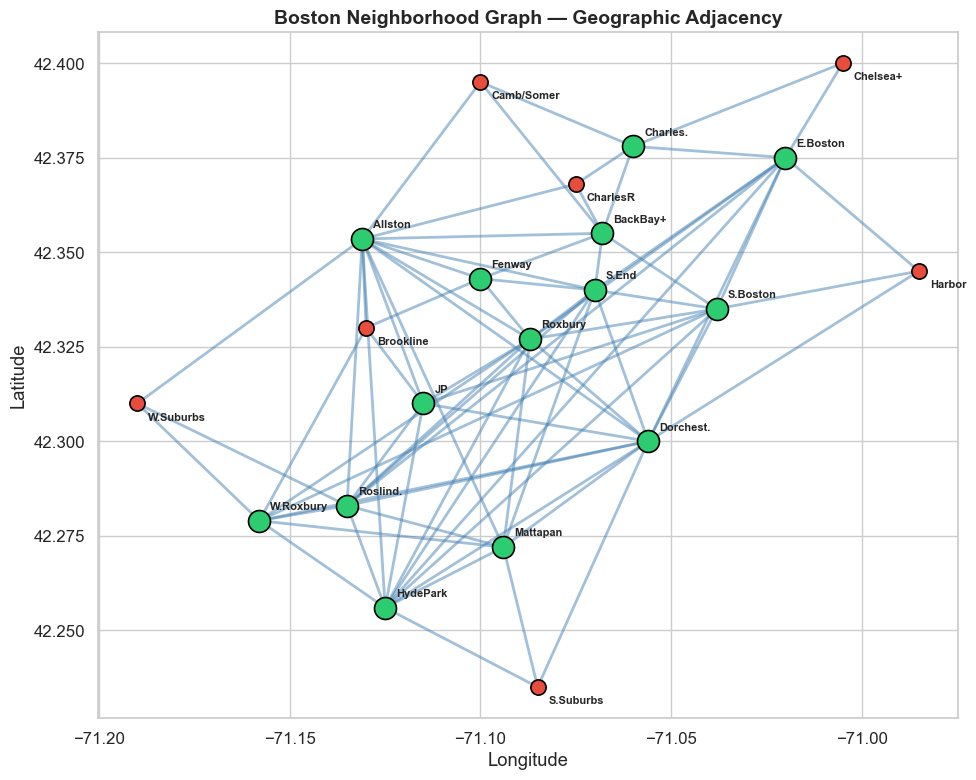

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

# Draw edges
for i in range(N_NODES):
    for j in range(i + 1, N_NODES):
        if A[i, j] > 0:
            n1, n2 = ALL_NODES[i], ALL_NODES[j]
            x = [COORDS[n1][0], COORDS[n2][0]]
            y = [COORDS[n1][1], COORDS[n2][1]]
            ax.plot(x, y, '-', color='steelblue', alpha=0.5, linewidth=2)

# Draw nodes
for idx, n in enumerate(ALL_NODES):
    color = '#e74c3c' if n in BG_SHORT_SET else '#2ecc71'
    size = 120 if n in BG_SHORT_SET else 250
    ax.scatter(*COORDS[n], s=size, c=color, edgecolors='black', linewidth=1.2, zorder=5)
    offset = (8, 8) if n not in BG_SHORT_SET else (8, -12)
    ax.annotate(n, COORDS[n], textcoords="offset points",
                xytext=offset, fontsize=8, fontweight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Boston Neighborhood Graph — Geographic Adjacency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


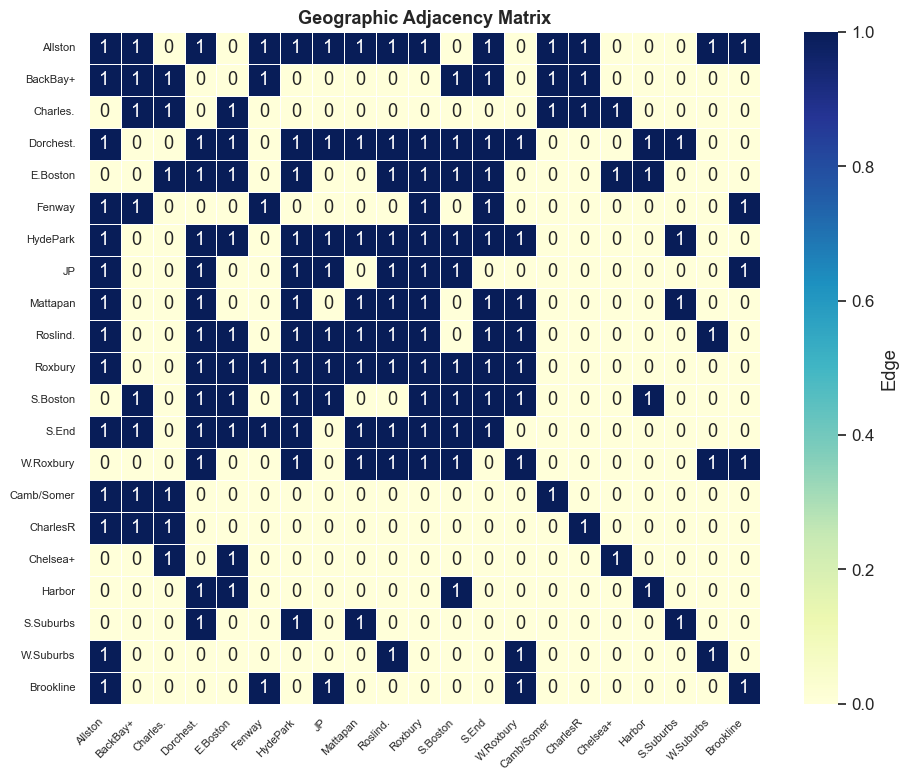

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(A, xticklabels=ALL_NODES, yticklabels=ALL_NODES,
            cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5,
            square=True, ax=ax, cbar_kws={'label': 'Edge'})
ax.set_title('Geographic Adjacency Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


## 4. Feature Assembly

We align all time series to a **common weekly index**, then build per-node feature vectors at each timestep.

**Per-node time-varying features (per lag):**
- Flu case rate (per 100k)
- Wastewater signal

**Per-node static features:**
- Population density, poverty rate, transit share, pct children, pct elderly, owner occupancy rate, no-vehicle rate, nonwhite share

**Global covariates:**
- Vaccination rate (season-level, forward-filled)
- City-wide ILI Count
- City-wide ED Count
- City-wide ILI ED Perc
- City-wide Flu Cases
- City-wide monthly confirmed cases


In [15]:
# -------------------------------------------------------
# Build common weekly time index from flu_pivot
# -------------------------------------------------------

# Align wastewater to same index (left join, forward fill gaps)
ww_aligned = ww_pivot.reindex(week_index, method='nearest', tolerance=pd.Timedelta('7D')).fillna(0)

# Align ED visits
ed_aligned = ed_merged.reindex(week_index, method='nearest', tolerance=pd.Timedelta('7D')).fillna(0)

# Align monthly demographic cases
gender_aligned = gender_monthly.reindex(week_index, method='nearest', tolerance=pd.Timedelta('7D')).fillna(0)

# Build vaccination time series (constant per season, mapped to weeks)
vacc_ts = pd.Series(0.0, index=week_index, name='vaccination_rate')
for _, vrow in vacc_df.iterrows():
    mask = (week_index >= vrow['start_date']) & (week_index <= vrow['end_date'])
    vacc_ts[mask] = vrow['vaccination_rate']
# Fill remaining with nearest non-zero
vacc_ts = vacc_ts.replace(0, np.nan).ffill().bfill().fillna(0.3)

# School calendar: approximate — in session weeks ~35-50 and 1-22 of calendar year
#school_indicator = np.array([
#    1.0 if (d.isocalendar()[1] <= 22 or d.isocalendar()[1] >= 36) else 0.0
#    for d in week_index
#])

N_WEEKS = len(week_index)
print(f"Common weekly index: {N_WEEKS} weeks")
print(f"  {week_index.min().date()} to {week_index.max().date()}")
print(f"  Flu rates shape: {flu_pivot.shape}")
print(f"  Wastewater shape: {ww_aligned.shape}")
print(f"  ED visits shape: {ed_aligned.shape}")


Common weekly index: 201 weeks
  2022-07-03 to 2026-05-03
  Flu rates shape: (201, 14)
  Wastewater shape: (201, 14)
  ED visits shape: (201, 4)


### Build PyTorch-ready tensors

In [16]:
LOOKBACK = 8                # weeks of history (was 4)
HORIZONS = [1, 2]        # multi-horizon training: predict 1, 2, and 4 weeks ahead
HORIZON  = HORIZONS[0]      # primary horizon for reporting
N_HORIZONS = len(HORIZONS)
MAX_HORIZON = max(HORIZONS)

# --- Per-neighborhood normalization ---
flu_np = flu_pivot.values.astype(np.float32)   # (T, 14)
ww_np = ww_aligned.values.astype(np.float32)   # (T, 14)

flu_means = flu_np.mean(axis=0, keepdims=True)
flu_stds = flu_np.std(axis=0, keepdims=True) + 1e-8
flu_norm = (flu_np - flu_means) / flu_stds

ww_means = ww_np.mean(axis=0, keepdims=True)
ww_stds = ww_np.std(axis=0, keepdims=True) + 1e-8
ww_norm = (ww_np - ww_means) / ww_stds

weather_norm = {}
weather_stats = {}
for col in WEATHER_COLS:
    arr = weather_arrays[col]
    means = arr.mean(axis=0, keepdims=True)
    stds = arr.std(axis=0, keepdims=True) + 1e-8
    weather_norm[col] = (arr - means) / stds
    weather_stats[col] = (means, stds)

ili_count_np = ed_aligned['ili_count'].values.astype(np.float32)
ed_count_np = ed_aligned['ed_count'].values.astype(np.float32)
ili_ed_perc_np = ed_aligned['ili_ed_perc'].values.astype(np.float32)
flu_cases_np = ed_aligned['flu_cases'].values.astype(np.float32)

ili_count_norm = (ili_count_np - ili_count_np.mean()) / (ili_count_np.std() + 1e-8)
ed_count_norm = (ed_count_np - ed_count_np.mean()) / (ed_count_np.std() + 1e-8)
ili_ed_perc_norm = (ili_ed_perc_np - ili_ed_perc_np.mean()) / (ili_ed_perc_np.std() + 1e-8)
flu_cases_norm = (flu_cases_np - flu_cases_np.mean()) / (flu_cases_np.std() + 1e-8)

monthly_cases_np = gender_aligned['monthly_cases'].values.astype(np.float32) if 'monthly_cases' in gender_aligned.columns else np.zeros(N_WEEKS, dtype=np.float32)
mc_norm = (monthly_cases_np - monthly_cases_np.mean()) / (monthly_cases_np.std() + 1e-8)

vacc_np = vacc_ts.values.astype(np.float32)
bg_static = np.full(static_np.shape[1], 0.5, dtype=np.float32)

# --- Detect temporal discontinuities ---
week_diffs = (flu_pivot.index.to_series().diff().dt.days).fillna(7).values
discontinuity_at = set(int(k) for k in np.where(week_diffs > 7)[0])
if discontinuity_at:
    print(f"Found {len(discontinuity_at)} temporal discontinuity(s) in week index.")
    for k in sorted(discontinuity_at):
        prev_d = flu_pivot.index[k-1].date()
        cur_d = flu_pivot.index[k].date()
        print(f"  gap at position {k}: {prev_d} -> {cur_d} ({int(week_diffs[k])} days)")

def sample_is_contiguous(t):
    """True if the LOOKBACK window + all HORIZON targets around t have no gap."""
    for k in range(t - LOOKBACK + 2, t + MAX_HORIZON + 1):
        if k in discontinuity_at:
            return False
    return True

def build_sample(t):
    """Build one (X, global, y) sample. y has shape (N_NEIGH, N_HORIZONS)."""
    node_feats = []
    for i in range(N_NEIGH):
        tv = []
        for lag in range(LOOKBACK):
            w = max(0, t - lag)
            tv.append(flu_norm[w, i])
            if USE_WASTEWATER:
                tv.append(ww_norm[w, i])
        if USE_WEATHER:
            for col in WEATHER_COLS:
                tv.append(weather_norm[col][t, i])
        parts = [np.asarray(tv, dtype=np.float32)]
        if USE_DEMOGRAPHICS:
            parts.append(static_np[i])
        node_feats.append(np.concatenate(parts))

    per_lag = 1 + (1 if USE_WASTEWATER else 0)
    bg_tv_len = LOOKBACK * per_lag + (len(WEATHER_COLS) if USE_WEATHER else 0)
    bg_parts = [np.zeros(bg_tv_len, dtype=np.float32)]
    if USE_DEMOGRAPHICS:
        bg_parts.append(bg_static)
    bg_row = np.concatenate(bg_parts)
    for _ in range(N_BG):          # one identical neutral anchor row per surrounding node
        node_feats.append(bg_row)

    X = np.array(node_feats, dtype=np.float32)

    g_parts = []
    if USE_VACCINATION:   g_parts.append(vacc_np[t])
    if USE_ILI_COUNT:     g_parts.append(ili_count_norm[t])
    if USE_ED_COUNT:      g_parts.append(ed_count_norm[t])
    if USE_ILI_ED_PERC:   g_parts.append(ili_ed_perc_norm[t])
    if USE_FLU_CASES:     g_parts.append(flu_cases_norm[t])
    if USE_MONTHLY_CASES: g_parts.append(mc_norm[t])
    g = np.array(g_parts, dtype=np.float32) if g_parts else np.zeros(0, dtype=np.float32)

    # Multi-horizon target: shape (N_NEIGH, N_HORIZONS)
    y = np.stack([flu_norm[min(t + h, N_WEEKS - 1), :] for h in HORIZONS], axis=1).astype(np.float32)

    return X, g, y

samples = []
sample_dates = []  # target = horizon-1 date
dropped_gap = 0
for t in range(LOOKBACK, N_WEEKS - MAX_HORIZON):
    if not sample_is_contiguous(t):
        dropped_gap += 1
        continue
    X, g, y = build_sample(t)
    samples.append((X, g, y))
    sample_dates.append(flu_pivot.index[t + HORIZON])

if dropped_gap:
    print(f"Dropped {dropped_gap} gap-crossing samples.")
print(f"Total samples: {len(samples)}")
N_FEAT = samples[0][0].shape[1]
N_GLOBAL = samples[0][1].shape[0]
print(f"Node features: {N_FEAT}")
print(f"Global features: {N_GLOBAL}")
print(f"Lookback: {LOOKBACK} weeks | Horizons: {HORIZONS}")

active_groups = [name for name, on in [
    ('wastewater', USE_WASTEWATER), ('weather', USE_WEATHER), ('demographics', USE_DEMOGRAPHICS),
    ('vaccination', USE_VACCINATION), ('ili_count', USE_ILI_COUNT),
    ('ed_count', USE_ED_COUNT), ('ili_ed_perc', USE_ILI_ED_PERC),
    ('flu_cases', USE_FLU_CASES), ('monthly_cases', USE_MONTHLY_CASES),
] if on]
print(f"Active feature groups: {active_groups}")


Total samples: 191
Node features: 22
Global features: 6
Lookback: 8 weeks | Horizons: [1, 2]
Active feature groups: ['weather', 'demographics', 'vaccination', 'ili_count', 'ed_count', 'ili_ed_perc', 'flu_cases', 'monthly_cases']


In [17]:
# --- Date-anchored train/val/test split ---
# Test set is FIXED to the [TEST_START_DATE, TEST_END_DATE] window so all model
# variants (original / ExcludeCovid / PostCovid) are evaluated on the same flu season.
# Validation = chronologically last 15% of remaining (non-test) samples.
test_start_ts = pd.Timestamp(TEST_START_DATE)
test_end_ts   = pd.Timestamp(TEST_END_DATE)

test_idx = [i for i, d in enumerate(sample_dates) if test_start_ts <= d <= test_end_ts]
non_test_idx = [i for i in range(len(samples)) if i not in set(test_idx)]

if not test_idx:
    raise ValueError(
        f"No samples fall in test window [{TEST_START_DATE}, {TEST_END_DATE}]. "
        f"Available target dates: {sample_dates[0].date()} to {sample_dates[-1].date()}"
    )

n_val = max(1, int(0.15 * len(non_test_idx))) if non_test_idx else 0
val_idx = non_test_idx[-n_val:] if n_val else []
train_idx = non_test_idx[:-n_val] if n_val else non_test_idx

train_samples = [samples[i] for i in train_idx]
val_samples   = [samples[i] for i in val_idx]
test_samples  = [samples[i] for i in test_idx]

print(f"Test window: {TEST_START_DATE} -> {TEST_END_DATE}")
print(f"  Test target dates: {sample_dates[test_idx[0]].date()} -> {sample_dates[test_idx[-1]].date()}")
if val_idx:
    print(f"  Val target dates:  {sample_dates[val_idx[0]].date()} -> {sample_dates[val_idx[-1]].date()}")
if train_idx:
    print(f"  Train target dates: {sample_dates[train_idx[0]].date()} -> {sample_dates[train_idx[-1]].date()}")
print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")


Test window: 2025-10-01 -> 2026-05-31
  Test target dates: 2025-10-05 -> 2026-04-26
  Val target dates:  2025-04-20 -> 2025-09-28
  Train target dates: 2022-09-04 -> 2025-04-13
Train: 137 | Val: 24 | Test: 30


### Data Exploration

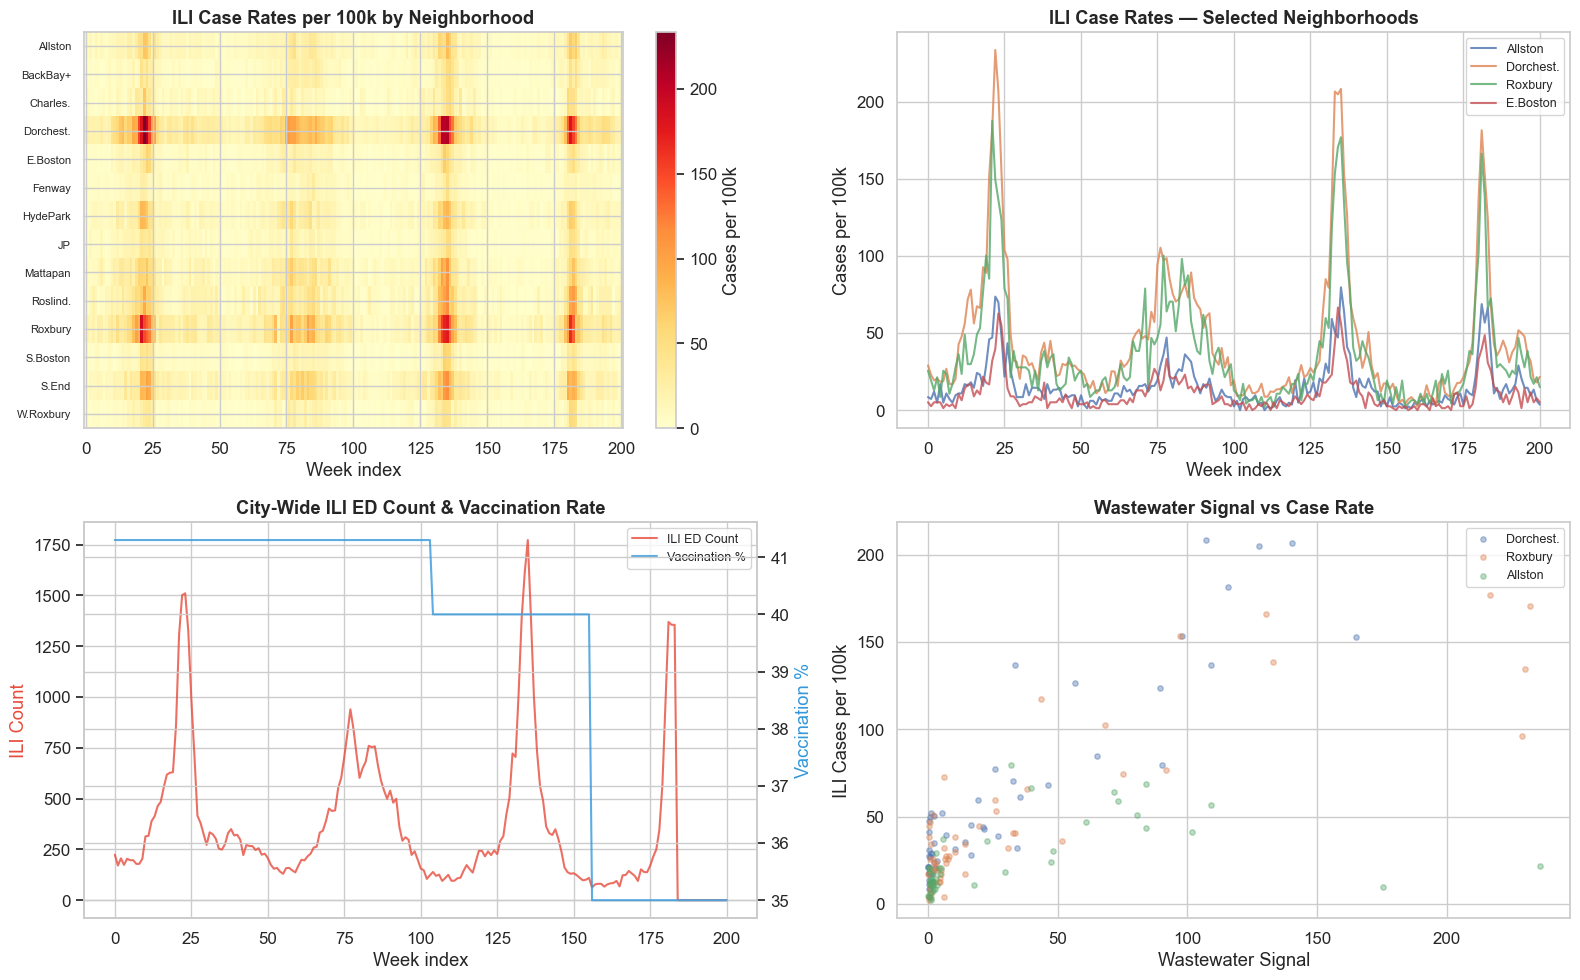

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Case rates heatmap
ax = axes[0, 0]
im = ax.imshow(flu_np.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(N_NEIGH))
ax.set_yticklabels(SHORT_NAMES, fontsize=8)
ax.set_xlabel('Week index')
ax.set_title('ILI Case Rates per 100k by Neighborhood', fontweight='bold')
plt.colorbar(im, ax=ax, label='Cases per 100k')

# (b) Selected neighborhood time series
ax = axes[0, 1]
for idx in [0, 3, 10, 4]:
    ax.plot(range(N_WEEKS), flu_np[:, idx], label=SHORT_NAMES[idx], alpha=0.8)
ax.set_xlabel('Week index')
ax.set_ylabel('Cases per 100k')
ax.set_title('ILI Case Rates — Selected Neighborhoods', fontweight='bold')
ax.legend(fontsize=9)

# (c) ED visits over time
ax = axes[1, 0]
ax.plot(range(N_WEEKS), ili_count_np, color='#e74c3c', alpha=0.8, label='ILI ED Count')
ax2 = ax.twinx()
ax2.plot(range(N_WEEKS), vacc_np * 100, color='#3498db', alpha=0.8, label='Vaccination %')
ax.set_xlabel('Week index')
ax.set_ylabel('ILI Count', color='#e74c3c')
ax2.set_ylabel('Vaccination %', color='#3498db')
ax.set_title('City-Wide ILI ED Count & Vaccination Rate', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# (d) Wastewater vs cases
ax = axes[1, 1]
# Only plot wastewater overlap period
for idx in [3, 10, 0]:
    mask = ww_np[:, idx] > 0
    ax.scatter(ww_np[mask, idx], flu_np[mask, idx], alpha=0.4, s=15, label=SHORT_NAMES[idx])
ax.set_xlabel('Wastewater Signal')
ax.set_ylabel('ILI Cases per 100k')
ax.set_title('Wastewater Signal vs Case Rate', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 5. GNN Model (PyTorch Geometric)

**Architecture:**
- 2× `GCNConv` layers with ReLU + dropout
- Global fusion: concatenate global covariates to every node embedding
- Output: linear head → per-node next-week flu rate prediction


In [19]:
class InfluenzaGNN(nn.Module):
    def __init__(self, n_node_feat, n_global, n_horizons=1, hidden1=64, hidden2=32, fusion_out=32, dropout=0.2):
        super().__init__()
        self.gcn1 = GCNConv(n_node_feat, hidden1)
        self.gcn2 = GCNConv(hidden1, hidden2)
        self.fusion = nn.Linear(hidden2 + n_global, fusion_out)
        self.output = nn.Linear(fusion_out, n_horizons)
        self.dropout = dropout
        self.n_horizons = n_horizons

    def forward(self, x, edge_index, g_vec, edge_weight=None):
        """
        x:          (N_NODES, n_node_feat)
        edge_index: (2, E)
        g_vec:      (n_global,)
        Returns:    (N_NODES, n_horizons) predicted values
        """
        h = F.relu(self.gcn1(x, edge_index, edge_weight))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.gcn2(h, edge_index, edge_weight))
        h = F.dropout(h, p=self.dropout, training=self.training)

        g_expanded = g_vec.unsqueeze(0).expand(h.size(0), -1)
        h = torch.cat([h, g_expanded], dim=1)
        h = F.relu(self.fusion(h))

        out = self.output(h)  # (N_NODES, n_horizons)
        return out


model = InfluenzaGNN(
    n_node_feat=N_FEAT,
    n_global=N_GLOBAL,
    n_horizons=N_HORIZONS,
    hidden1=64,
    hidden2=32,
    fusion_out=32,
    dropout=0.2,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


InfluenzaGNN(
  (gcn1): GCNConv(22, 64)
  (gcn2): GCNConv(64, 32)
  (fusion): Linear(in_features=38, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=2, bias=True)
)

Total parameters: 4,866


### Architecture Diagram

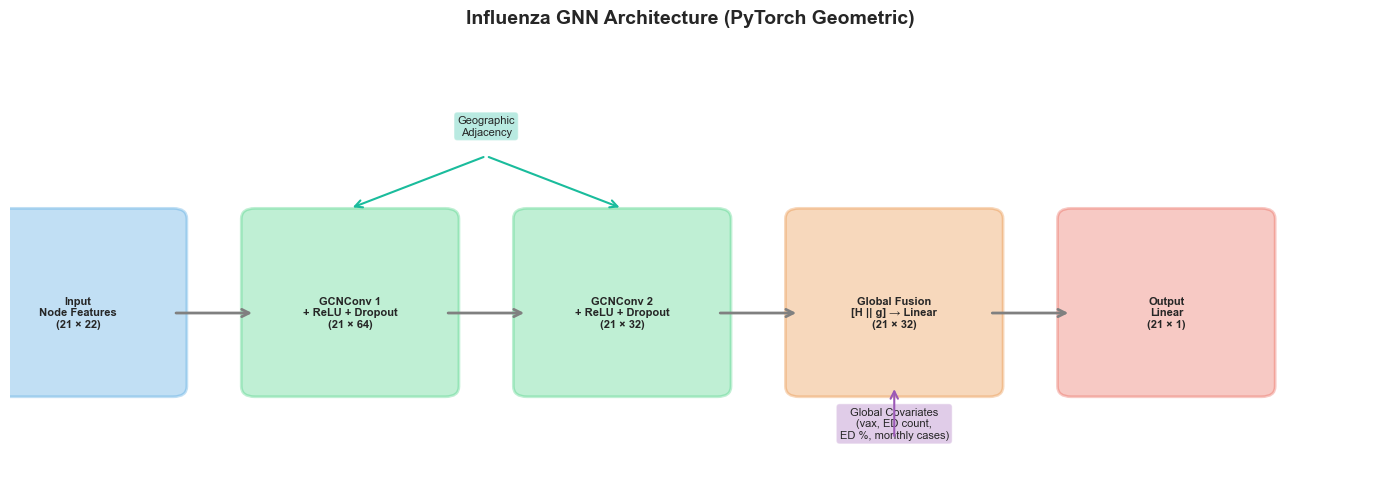

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

boxes = [
    (0.5, 1.5, f'Input\nNode Features\n({N_NODES} × {N_FEAT})', '#3498db'),
    (2.5, 1.5, f'GCNConv 1\n+ ReLU + Dropout\n({N_NODES} × 64)', '#2ecc71'),
    (4.5, 1.5, f'GCNConv 2\n+ ReLU + Dropout\n({N_NODES} × 32)', '#2ecc71'),
    (6.5, 1.5, f'Global Fusion\n[H || g] → Linear\n({N_NODES} × 32)', '#e67e22'),
    (8.5, 1.5, f'Output\nLinear\n({N_NODES} × 1)', '#e74c3c'),
]

for x, y, text, color in boxes:
    rect = mpatches.FancyBboxPatch((x - 0.7, y - 0.7), 1.4, 1.6,
                                     boxstyle="round,pad=0.1",
                                     facecolor=color, alpha=0.3, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=8, fontweight='bold')

for i in range(len(boxes) - 1):
    ax.annotate('', xy=(boxes[i + 1][0] - 0.7, boxes[i + 1][1]),
                xytext=(boxes[i][0] + 0.7, boxes[i][1]),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

ax.annotate(f'Global Covariates\n(vax, ED count,\nED %, monthly cases)',
            xy=(6.5, 0.6), fontsize=8, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='#9b59b6', alpha=0.3))
ax.annotate('', xy=(6.5, 0.8), xytext=(6.5, 0.3),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#9b59b6'))

ax.annotate('Geographic\nAdjacency',
            xy=(3.5, 3.2), fontsize=8, ha='center',
            bbox=dict(boxstyle='round', facecolor='#1abc9c', alpha=0.3))
ax.annotate('', xy=(2.5, 2.5), xytext=(3.5, 3.0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#1abc9c'))
ax.annotate('', xy=(4.5, 2.5), xytext=(3.5, 3.0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#1abc9c'))

ax.set_title('Influenza GNN Architecture (PyTorch Geometric)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 6. Training

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)
EPOCHS = 120

train_losses = []
val_losses = []
best_val = float('inf')
best_state = None
patience_counter = 0
PATIENCE = 25

def multi_horizon_loss(pred, y_t):
    """pred: (N_NODES, N_HORIZONS); y_t: (N_NEIGH, N_HORIZONS). Average MSE across horizons."""
    return criterion(pred[:N_NEIGH], y_t)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    indices = np.random.permutation(len(train_samples))

    for idx in indices:
        X, g, y = train_samples[idx]
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        g_t = torch.tensor(g, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.float32).to(device)  # (N_NEIGH, N_HORIZONS)

        optimizer.zero_grad()
        pred = model(X_t, edge_index_dev, g_t, edge_weight_dev)
        loss = multi_horizon_loss(pred, y_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_samples))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, g, y in val_samples:
            X_t = torch.tensor(X, dtype=torch.float32).to(device)
            g_t = torch.tensor(g, dtype=torch.float32).to(device)
            y_t = torch.tensor(y, dtype=torch.float32).to(device)
            pred = model(X_t, edge_index_dev, g_t, edge_weight_dev)
            val_loss += multi_horizon_loss(pred, y_t).item()
    val_losses.append(val_loss / len(val_samples))

    scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train MSE: {train_losses[-1]:.6f} | "
              f"Val MSE: {val_losses[-1]:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
print(f"\nBest validation MSE: {best_val:.6f}")


Epoch   1 | Train MSE: 0.525428 | Val MSE: 0.051880 | LR: 0.003000


Epoch  10 | Train MSE: 0.229624 | Val MSE: 0.046670 | LR: 0.003000


Epoch  20 | Train MSE: 0.230972 | Val MSE: 0.067735 | LR: 0.003000


Epoch  30 | Train MSE: 0.190212 | Val MSE: 0.049048 | LR: 0.001500



Early stopping at epoch 35

Best validation MSE: 0.046670


### Training & Validation Loss

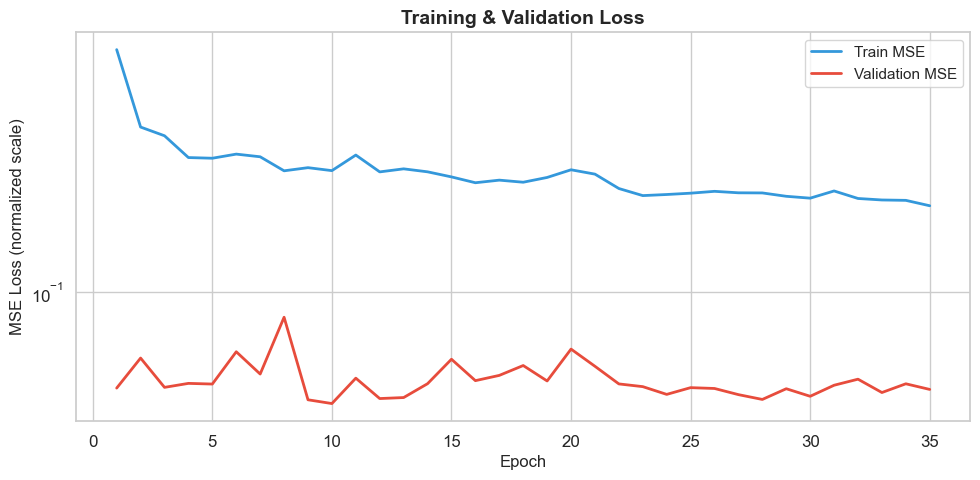

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses) + 1), train_losses, label='Train MSE', color='#3498db', linewidth=2)
ax.plot(range(1, len(val_losses) + 1), val_losses, label='Validation MSE', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss (normalized scale)', fontsize=12)
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_yscale('log')
plt.tight_layout()
plt.show()


## 7. Test Set Evaluation

In [23]:
# ============================================================
# Test-set inference with MC-Dropout predictive uncertainty
# ============================================================
# The model uses F.dropout(..., training=self.training) and has no
# BatchNorm / nn.Dropout submodules, so model.train() activates ONLY
# dropout (GCNConv / Linear stay deterministic). We run N_MC stochastic
# forward passes to obtain a predictive distribution.
#
# A 95% PREDICTIVE interval needs two variance components:
#   * epistemic (model) variance  -> spread across the N_MC dropout passes
#   * aleatoric (observation) noise -> estimated from VALIDATION residuals
#     (held-out, so no test leakage), per neighborhood & horizon.
# Pure MC-dropout (epistemic only) badly under-covers (~observation noise is
# ignored), so we combine both: band = mean +/- 1.96 * sqrt(epi + aleo).
N_MC = 100
Z95 = 1.959964
torch.manual_seed(123)   # reproducible MC sampling

flu_means_b = flu_means.flatten()[None, :, None]
flu_stds_b = flu_stds.flatten()[None, :, None]


def mc_forward(sample_list):
    """Return (mc_denorm, targets_denorm) for a list of samples.
    mc_denorm: (N_MC, N, N_NEIGH, N_HORIZONS); targets_denorm: (N, N_NEIGH, N_HORIZONS)."""
    stack, targs = [], []
    with torch.no_grad():
        for s in range(N_MC):
            per_week = []
            for X, g, y in sample_list:
                X_t = torch.tensor(X, dtype=torch.float32).to(device)
                g_t = torch.tensor(g, dtype=torch.float32).to(device)
                pred = model(X_t, edge_index_dev, g_t, edge_weight_dev)         # (N_NODES, N_HORIZONS)
                per_week.append(pred[:N_NEIGH].cpu().numpy())  # (N_NEIGH, N_HORIZONS)
                if s == 0:
                    targs.append(y)
            stack.append(np.stack(per_week, axis=0))           # (N, N_NEIGH, N_HORIZONS)
    mc_d = np.stack(stack, axis=0) * flu_stds_b[None] + flu_means_b[None]
    targ_d = np.stack(targs, axis=0) * flu_stds_b + flu_means_b
    return mc_d, targ_d


model.train()            # enable dropout for MC sampling
mc_denorm, targets_all_h_denorm = mc_forward(test_samples)
if len(val_samples):
    val_mc_denorm, val_targets_denorm = mc_forward(val_samples)
model.eval()

# Point estimate = MC mean; epistemic variance = spread across MC passes
preds_all_h_denorm = mc_denorm.mean(axis=0)                 # (N_test, N_NEIGH, N_HORIZONS)
epistemic_var = mc_denorm.var(axis=0)                       # (N_test, N_NEIGH, N_HORIZONS)

# Aleatoric (observation) variance per (neighborhood, horizon) from validation
# residuals; fall back to test residuals if no validation set is available.
if len(val_samples):
    aleatoric_var = np.mean((val_mc_denorm.mean(axis=0) - val_targets_denorm) ** 2, axis=0)
else:
    aleatoric_var = np.mean((preds_all_h_denorm - targets_all_h_denorm) ** 2, axis=0)

total_std = np.sqrt(epistemic_var + aleatoric_var[None, :, :])   # (N_test, N_NEIGH, N_HORIZONS)
preds_lower_all_h = np.maximum(0.0, preds_all_h_denorm - Z95 * total_std)  # rates are non-negative
preds_upper_all_h = preds_all_h_denorm + Z95 * total_std

# Primary evaluation: horizon-1
preds_arr = preds_all_h_denorm[:, :, 0]    # (N_test, N_NEIGH)
preds_lower_arr = preds_lower_all_h[:, :, 0]
preds_upper_arr = preds_upper_all_h[:, :, 0]
targets_arr = targets_all_h_denorm[:, :, 0]


def lins_ccc(y_pred, y_true):
    """Lin's Concordance Correlation Coefficient: agreement between two
    continuous measurements = precision (Pearson r) x accuracy (closeness of
    the best-fit line to the 45-degree identity line). Symmetric, range [-1, 1];
    1 = perfect agreement. Uses population moments (ddof=0)."""
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    mp, mt = y_pred.mean(), y_true.mean()
    vp, vt = y_pred.var(), y_true.var()
    cov = np.mean((y_pred - mp) * (y_true - mt))
    denom = vp + vt + (mp - mt) ** 2
    return float(2 * cov / denom) if denom > 0 else 0.0

# --- Core metrics on horizon-1 ---
mae = np.mean(np.abs(preds_arr - targets_arr))
rmse = np.sqrt(np.mean((preds_arr - targets_arr) ** 2))
ss_res = np.sum((targets_arr - preds_arr) ** 2)
ss_tot = np.sum((targets_arr - targets_arr.mean()) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
mask = np.abs(targets_arr) > 1e-6
mape = np.mean(np.abs((targets_arr[mask] - preds_arr[mask]) / targets_arr[mask])) * 100 if mask.any() else float('nan')

# Empirical 95% CI coverage: fraction of actuals falling inside the MC-Dropout band
ci_coverage = float(np.mean((targets_arr >= preds_lower_arr) & (targets_arr <= preds_upper_arr)))

flat_targets = targets_arr.flatten()
flat_preds = preds_arr.flatten()
_, overall_pval = pearsonr(flat_targets, flat_preds)

# --- Per-neighborhood (across-time) Spearman + Lin's CCC ---
# Spearman rho = monotonic rank correlation (does the model order the weeks
# correctly?). Lin's CCC = agreement on the actual magnitudes (does the model
# hit the right case-rate level, not just the right ranking?). CCC penalises
# both poor correlation and systematic over/under-prediction (bias / scale),
# so it complements Spearman's rank-only view. CCC is symmetric.
corrs = []
pvals = []
ccc_corrs = []
for i in range(N_NEIGH):
    if targets_arr[:, i].std() > 0 and preds_arr[:, i].std() > 0:
        r, p = spearmanr(preds_arr[:, i], targets_arr[:, i])
        corrs.append(r); pvals.append(p)
        ccc_corrs.append(lins_ccc(preds_arr[:, i], targets_arr[:, i]))
    else:
        corrs.append(0.0); pvals.append(1.0)
        ccc_corrs.append(0.0)
mean_spearman_temporal = float(np.mean(corrs))
mean_spearman = mean_spearman_temporal  # backward-compat alias for downstream cells
mean_ccc_temporal = float(np.mean(ccc_corrs))
mean_ccc = mean_ccc_temporal            # alias for downstream cells

# --- Per-week cross-neighborhood Spearman + CCC ---
# For each test week, compare the 14 neighborhoods by predicted vs. actual.
# Answers: "Does the model identify which neighborhoods will be hit hardest each week?"
# NOTE: only N_NEIGH (~14) points per week, so both metrics are noisy week-to-week;
# we summarise with the mean/median across weeks.
cross_corrs = []
cross_pvals = []
ccc_cross_corrs = []
for t in range(preds_arr.shape[0]):
    if preds_arr[t, :].std() > 0 and targets_arr[t, :].std() > 0:
        r, p = spearmanr(preds_arr[t, :], targets_arr[t, :])
        cross_corrs.append(r); cross_pvals.append(p)
        ccc_cross_corrs.append(lins_ccc(preds_arr[t, :], targets_arr[t, :]))
cross_corrs = np.array(cross_corrs)
ccc_cross_corrs = np.array(ccc_cross_corrs)
mean_spearman_cross = float(np.mean(cross_corrs)) if len(cross_corrs) else float('nan')
median_spearman_cross = float(np.median(cross_corrs)) if len(cross_corrs) else float('nan')
mean_ccc_cross = float(np.mean(ccc_cross_corrs)) if len(ccc_cross_corrs) else float('nan')
median_ccc_cross = float(np.median(ccc_cross_corrs)) if len(ccc_cross_corrs) else float('nan')

# --- Per-horizon MAE/RMSE breakdown ---
per_horizon = []
for h_idx, h in enumerate(HORIZONS):
    p_h = preds_all_h_denorm[:, :, h_idx]
    t_h = targets_all_h_denorm[:, :, h_idx]
    mae_h = np.mean(np.abs(p_h - t_h))
    rmse_h = np.sqrt(np.mean((p_h - t_h) ** 2))
    ss_r = np.sum((t_h - p_h) ** 2)
    ss_t = np.sum((t_h - t_h.mean()) ** 2)
    r2_h = 1 - ss_r / ss_t if ss_t > 0 else 0.0
    per_horizon.append((h, mae_h, rmse_h, r2_h))

print("=" * 70)
print(f"TEST SET RESULTS — horizon-1 (primary)   [MC-Dropout, N_MC={N_MC}]")
print("=" * 70)
print(f"MAE:                          {mae:.2f} cases per 100k")
print(f"RMSE:                         {rmse:.2f} cases per 100k")
print(f"R²:                           {r2:.4f}")
print(f"MAPE:                         {mape:.2f}%")
print(f"Pearson p-value:              {overall_pval:.4e}")
print(f"95% CI coverage (actual in band): {ci_coverage * 100:.1f}%")
print(f"Per-neighborhood (temporal)   Spearman ρ: {mean_spearman_temporal:.4f}  |  Lin's CCC: {mean_ccc_temporal:.4f}")
print(f"Per-week (cross-neighborhood) Spearman ρ: mean={mean_spearman_cross:.4f} median={median_spearman_cross:.4f}")
print(f"Per-week (cross-neighborhood) Lin's CCC:  mean={mean_ccc_cross:.4f} median={median_ccc_cross:.4f}")
print()
print("Per-horizon breakdown:")
print(f"  {'Horizon':>8s} | {'MAE':>6s} | {'RMSE':>6s} | {'R²':>6s}")
for h, m, r_, r2_ in per_horizon:
    print(f"  {h:>8d} | {m:>6.2f} | {r_:>6.2f} | {r2_:>6.3f}")
print()
print("Per-neighborhood (temporal) Spearman ρ / Lin's CCC:")
for i, n in enumerate(SHORT_NAMES):
    print(f"  {n:12s}: ρ = {corrs[i]:.4f} (p = {pvals[i]:.4e})   CCC = {ccc_corrs[i]:.4f}")

TEST SET RESULTS — horizon-1 (primary)   [MC-Dropout, N_MC=100]
MAE:                          8.84 cases per 100k
RMSE:                         12.98 cases per 100k
R²:                           0.7163
MAPE:                         58.44%
Pearson p-value:              4.2036e-145
95% CI coverage (actual in band): 48.1%
Per-neighborhood (temporal)   Spearman ρ: 0.2898  |  Lin's CCC: 0.8165
Per-week (cross-neighborhood) Spearman ρ: mean=0.6904 median=0.7363
Per-week (cross-neighborhood) Lin's CCC:  mean=0.5137 median=0.5390

Per-horizon breakdown:
   Horizon |    MAE |   RMSE |     R²
         1 |   8.84 |  12.98 |  0.716
         2 |  10.30 |  16.85 |  0.520

Per-neighborhood (temporal) Spearman ρ / Lin's CCC:
  Allston     : ρ = 0.2701 (p = 1.4893e-01)   CCC = 0.8640
  BackBay+    : ρ = 0.2896 (p = 1.2065e-01)   CCC = 0.7483
  Charles.    : ρ = 0.2705 (p = 1.4828e-01)   CCC = 0.7570
  Dorchest.   : ρ = 0.3446 (p = 6.2201e-02)   CCC = 0.8450
  E.Boston    : ρ = 0.2112 (p = 2.6247e-01)  

### Predicted vs Actual — Time Series

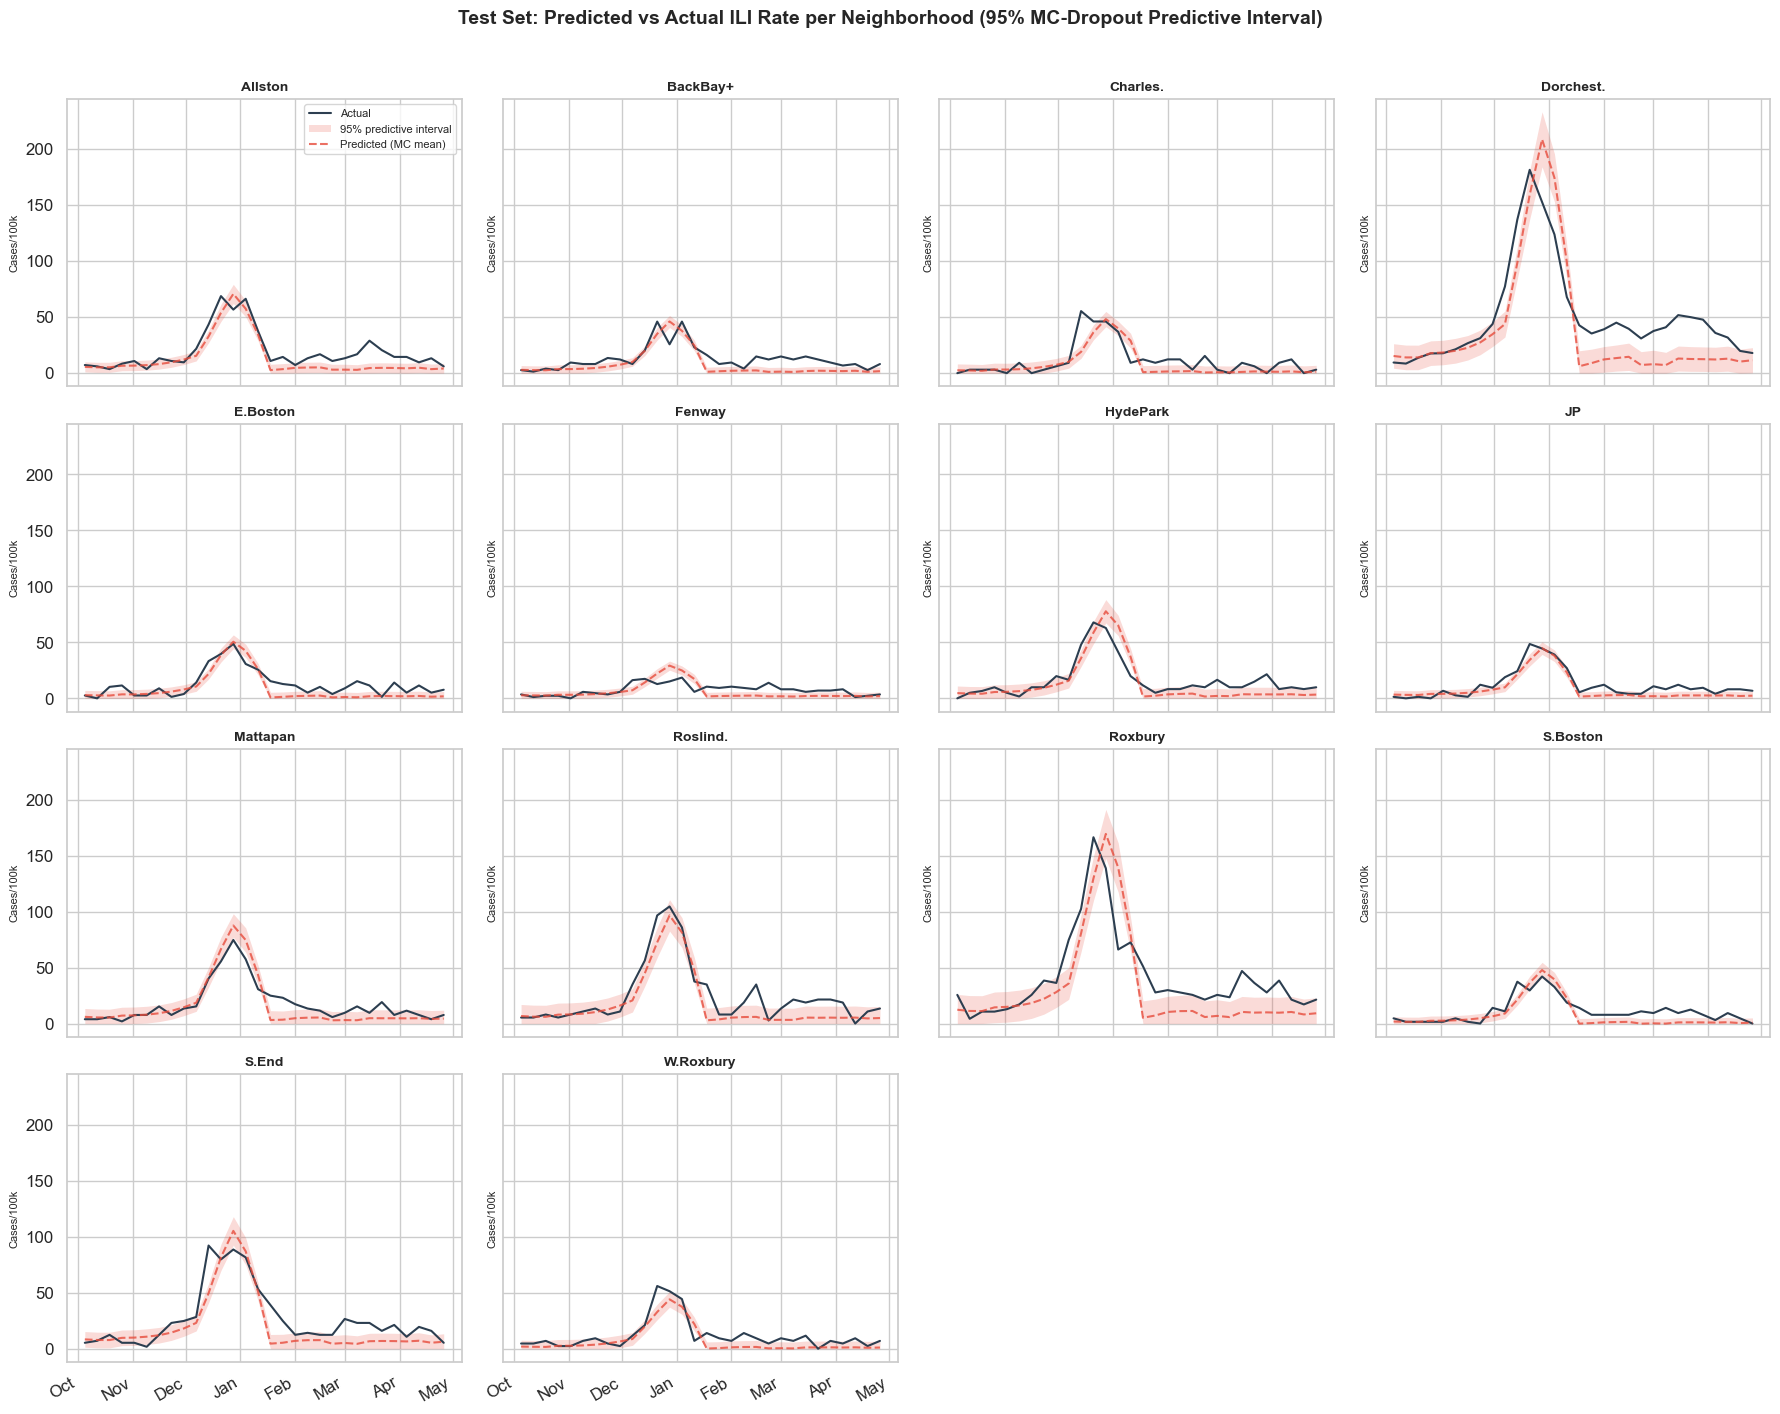

In [24]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharex=True, sharey=True)
axes_flat = axes.flatten()

# Test set x-axis = actual target dates from the date-anchored split
test_weeks_idx = [sample_dates[i] for i in test_idx]

for i in range(N_NEIGH):
    ax = axes_flat[i]
    ax.plot(test_weeks_idx, targets_arr[:, i], label='Actual', color='#2c3e50', linewidth=1.5)
    ax.fill_between(test_weeks_idx, preds_lower_arr[:, i], preds_upper_arr[:, i],
                    color='#e74c3c', alpha=0.2, linewidth=0, label='95% predictive interval')
    ax.plot(test_weeks_idx, preds_arr[:, i], label='Predicted (MC mean)', color='#e74c3c',
            linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_title(SHORT_NAMES[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Cases/100k', fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)

for i in range(N_NEIGH, len(axes_flat)):
    axes_flat[i].axis('off')

for ax in axes_flat[:N_NEIGH]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.gcf().autofmt_xdate()
plt.suptitle('Test Set: Predicted vs Actual ILI Rate per Neighborhood (95% MC-Dropout Predictive Interval)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

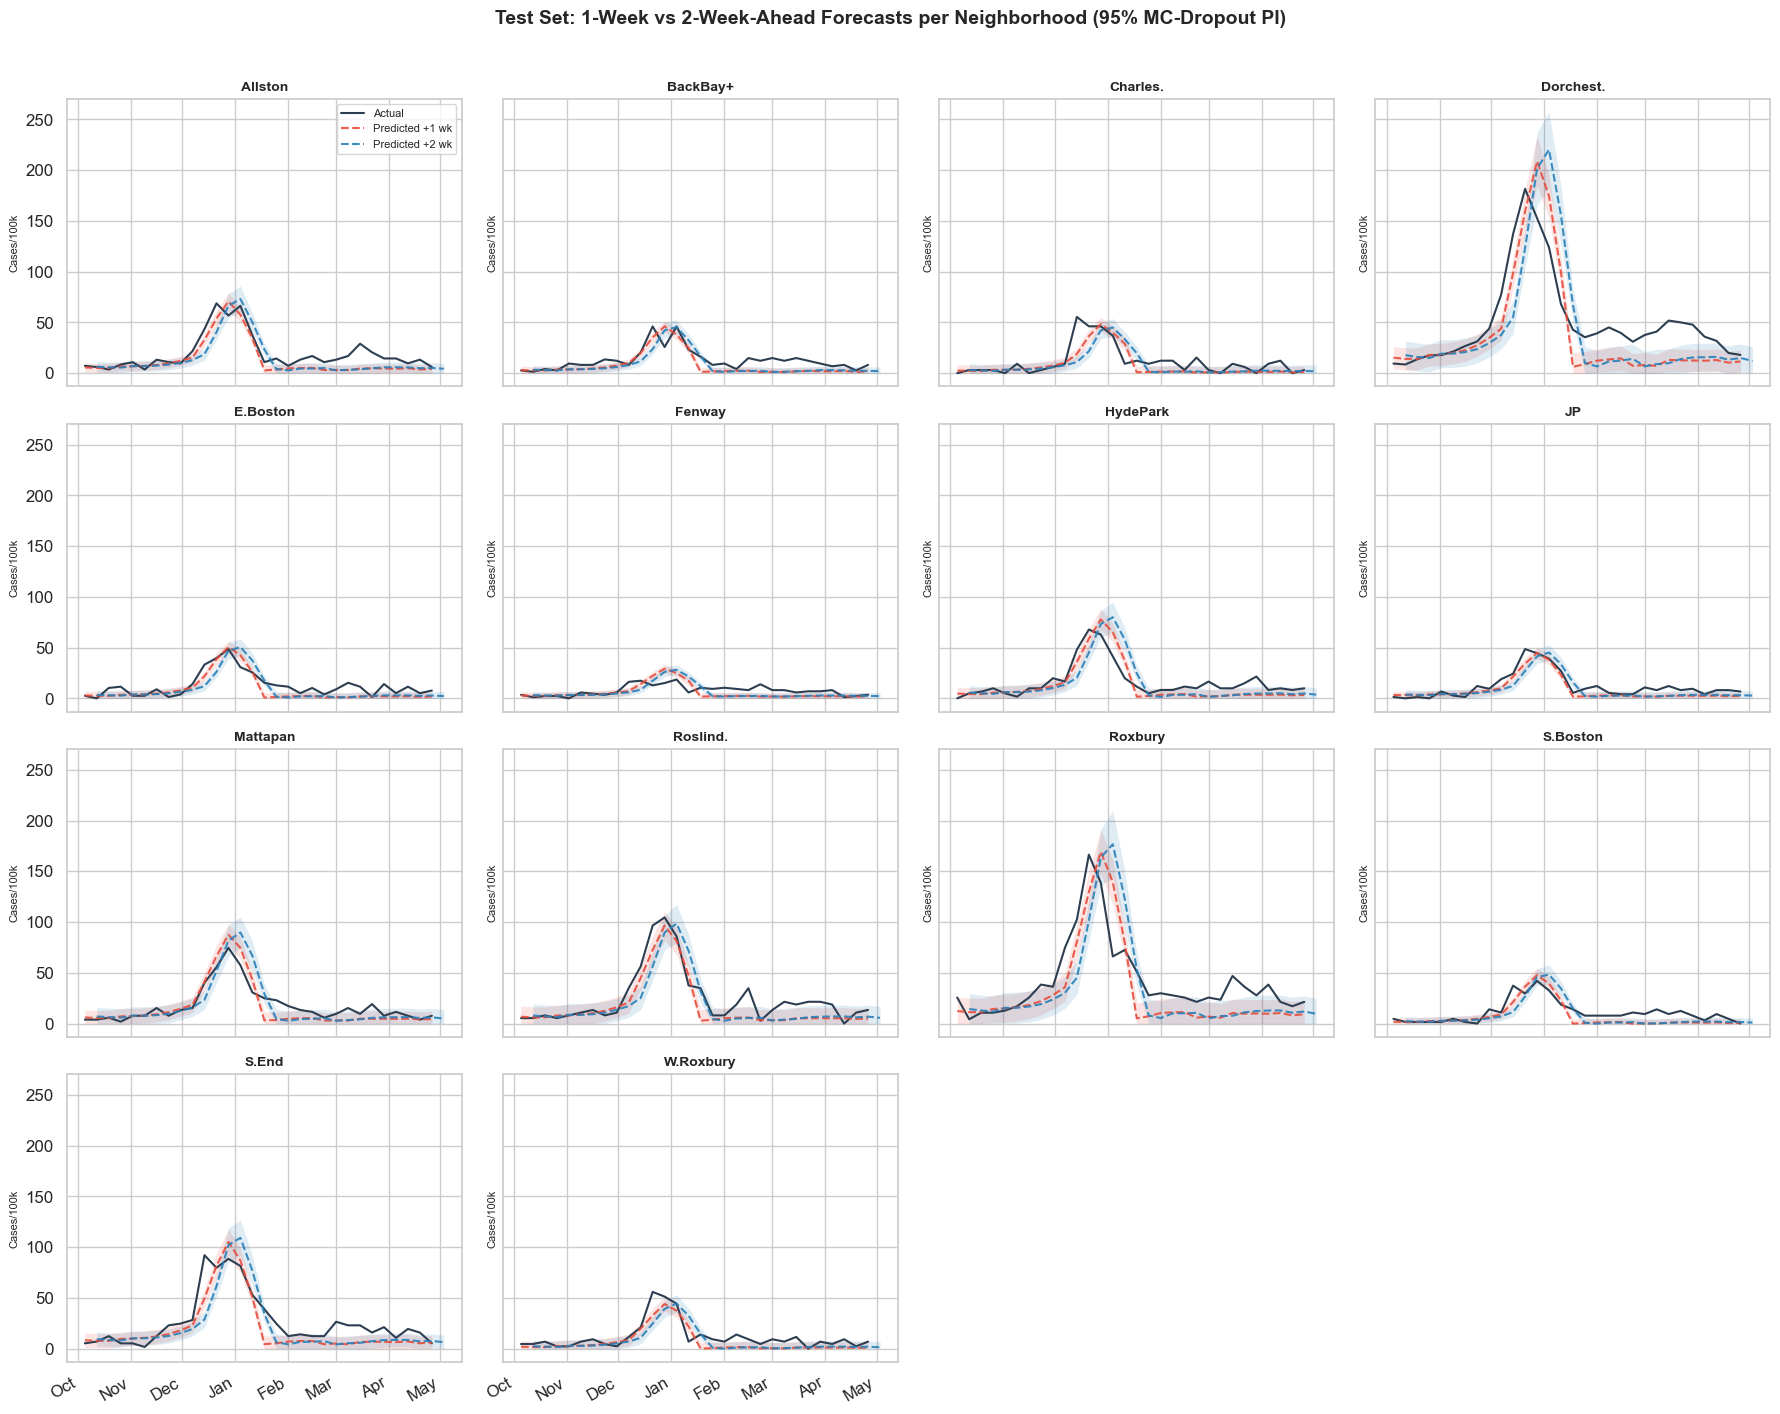

In [25]:
# --- Multi-horizon comparison: 1-week vs 2-week-ahead forecasts ---
# Same per-neighborhood layout as the horizon-1 plot above, but overlays BOTH
# forecast horizons in distinct colors. Each horizon is drawn at the week it
# actually forecasts (the 2-week-ahead target sits one week later than the
# 1-week-ahead target), so both prediction lines stay temporally aligned with
# the actual curve. Works regardless of which horizon HORIZON points at.
h1_idx = HORIZONS.index(1)
h2_idx = HORIZONS.index(2)

base_dates = [sample_dates[i] for i in test_idx]                     # = week (t + HORIZON)
h1_dates = [d + pd.Timedelta(weeks=(1 - HORIZON)) for d in base_dates]
h2_dates = [d + pd.Timedelta(weeks=(2 - HORIZON)) for d in base_dates]

C_ACTUAL = '#2c3e50'
C_H1 = '#e74c3c'   # 1-week-ahead
C_H2 = '#2980b9'   # 2-week-ahead

fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i in range(N_NEIGH):
    ax = axes_flat[i]
    # Actual ILI reference curve
    ax.plot(h1_dates, targets_all_h_denorm[:, i, h1_idx], label='Actual',
            color=C_ACTUAL, linewidth=1.5)
    # Horizon-1 (+1 week)
    ax.fill_between(h1_dates, preds_lower_all_h[:, i, h1_idx], preds_upper_all_h[:, i, h1_idx],
                    color=C_H1, alpha=0.15, linewidth=0)
    ax.plot(h1_dates, preds_all_h_denorm[:, i, h1_idx], label='Predicted +1 wk',
            color=C_H1, linewidth=1.5, linestyle='--', alpha=0.9)
    # Horizon-2 (+2 weeks)
    ax.fill_between(h2_dates, preds_lower_all_h[:, i, h2_idx], preds_upper_all_h[:, i, h2_idx],
                    color=C_H2, alpha=0.15, linewidth=0)
    ax.plot(h2_dates, preds_all_h_denorm[:, i, h2_idx], label='Predicted +2 wk',
            color=C_H2, linewidth=1.5, linestyle='--', alpha=0.9)
    ax.set_title(SHORT_NAMES[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Cases/100k', fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)

for i in range(N_NEIGH, len(axes_flat)):
    axes_flat[i].axis('off')

for ax in axes_flat[:N_NEIGH]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.gcf().autofmt_xdate()
plt.suptitle('Test Set: 1-Week vs 2-Week-Ahead Forecasts per Neighborhood (95% MC-Dropout PI)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Predicted vs Actual — Scatter

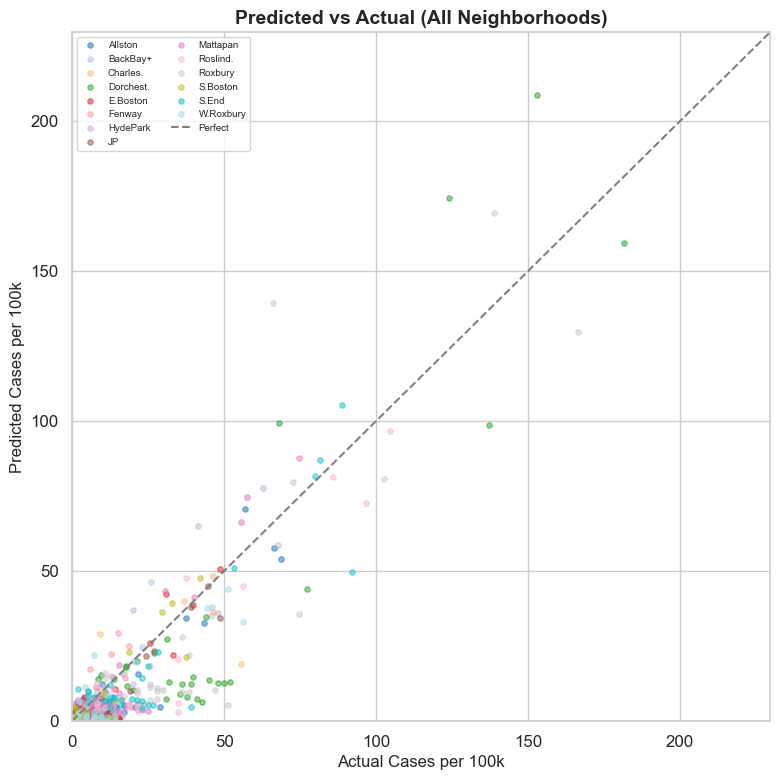

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab20(np.linspace(0, 1, N_NEIGH))

for i in range(N_NEIGH):
    ax.scatter(targets_arr[:, i], preds_arr[:, i], c=[colors[i]], s=15,
               alpha=0.5, label=SHORT_NAMES[i])

lims = [min(0, targets_arr.min(), preds_arr.min()),
        max(targets_arr.max(), preds_arr.max()) * 1.1]
ax.plot(lims, lims, '--', color='gray', linewidth=1.5, label='Perfect')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Cases per 100k', fontsize=12)
ax.set_ylabel('Predicted Cases per 100k', fontsize=12)
ax.set_title('Predicted vs Actual (All Neighborhoods)', fontsize=14, fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()


### Spatial Prediction Heatmap (Peak Flu Week)

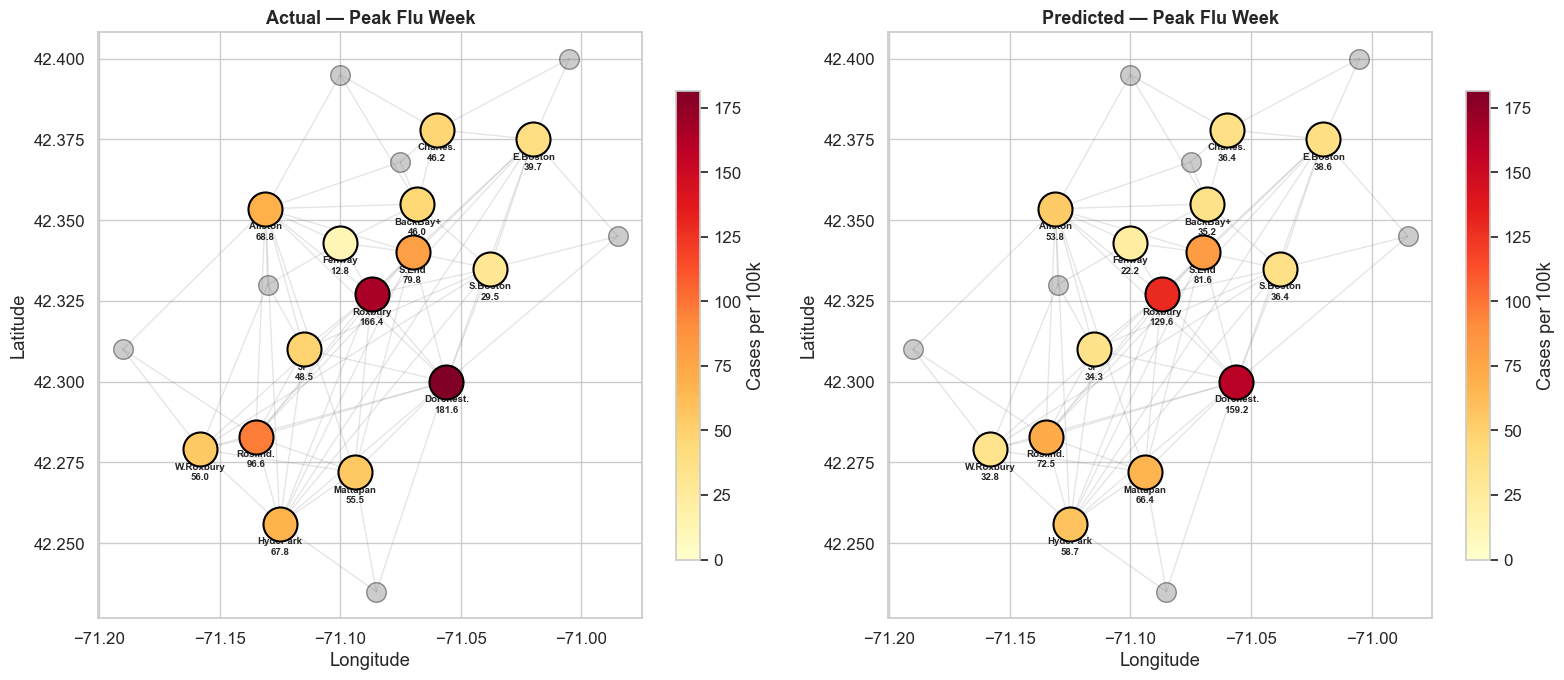

In [27]:
peak_idx = np.argmax(targets_arr.mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (data_slice, title) in enumerate([(targets_arr[peak_idx], 'Actual'),
                                                (preds_arr[peak_idx], 'Predicted')]):
    ax = axes[ax_idx]
    vmin = 0
    vmax = max(targets_arr[peak_idx].max(), preds_arr[peak_idx].max())
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.YlOrRd

    # Edges
    for i in range(N_NODES):
        for j in range(i + 1, N_NODES):
            if A[i, j] > 0:
                n1, n2 = ALL_NODES[i], ALL_NODES[j]
                ax.plot([COORDS[n1][0], COORDS[n2][0]],
                        [COORDS[n1][1], COORDS[n2][1]],
                        '-', color='gray', alpha=0.2, linewidth=1)

    for i, n in enumerate(SHORT_NAMES):
        color = cmap(norm(data_slice[i]))
        ax.scatter(*COORDS[n], s=600, c=[color], edgecolors='black', linewidth=1.5, zorder=5)
        ax.annotate(f"{n}\n{data_slice[i]:.1f}", COORDS[n],
                    textcoords="offset points", xytext=(0, -22),
                    fontsize=7, ha='center', fontweight='bold')

    for _bn in BG_SHORT:
        ax.scatter(*COORDS[_bn], s=200, c='gray', edgecolors='black',
                   linewidth=1, zorder=5, alpha=0.4)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label='Cases per 100k', shrink=0.8)
    ax.set_title(f'{title} — Peak Flu Week', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


### Per-Neighborhood Spearman Correlation

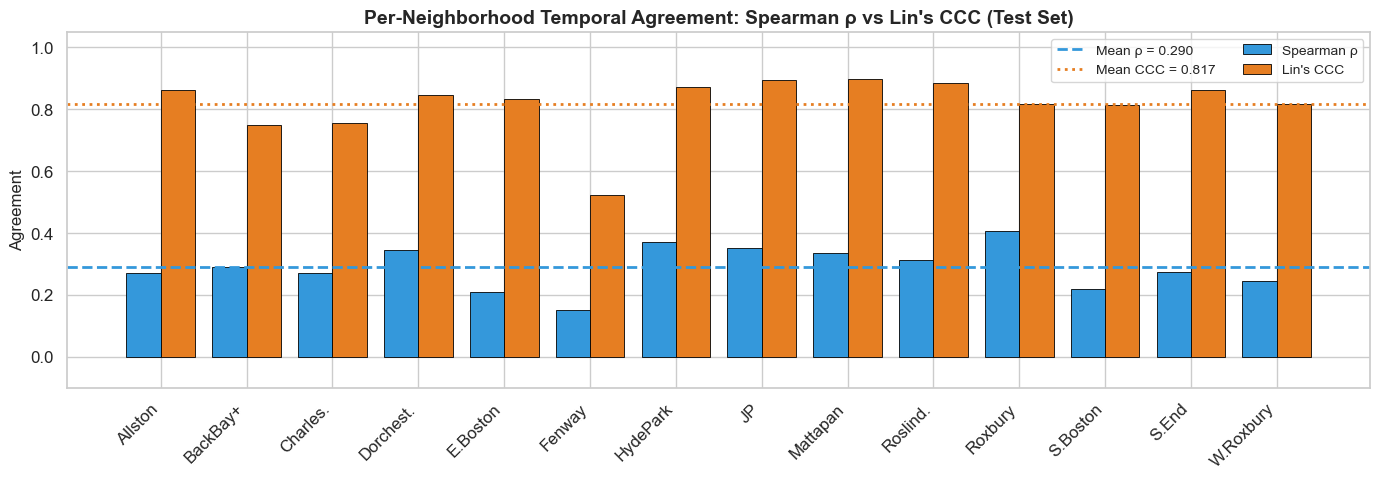

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(N_NEIGH)
w = 0.4
ax.bar(x - w / 2, corrs, w, label='Spearman ρ', color='#3498db', edgecolor='black', linewidth=0.6)
ax.bar(x + w / 2, ccc_corrs, w, label="Lin's CCC", color='#e67e22', edgecolor='black', linewidth=0.6)
ax.axhline(y=mean_spearman, color='#3498db', linestyle='--', linewidth=2,
           label=f'Mean ρ = {mean_spearman:.3f}')
ax.axhline(y=mean_ccc, color='#e67e22', linestyle=':', linewidth=2,
           label=f'Mean CCC = {mean_ccc:.3f}')
ax.set_ylabel('Agreement', fontsize=12)
ax.set_title("Per-Neighborhood Temporal Agreement: Spearman ρ vs Lin's CCC (Test Set)",
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, rotation=45, ha='right')
ax.set_ylim(min(-0.1, float(np.min(ccc_corrs)), float(np.min(corrs))), 1.05)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

### Spatial Spread Over Consecutive Weeks

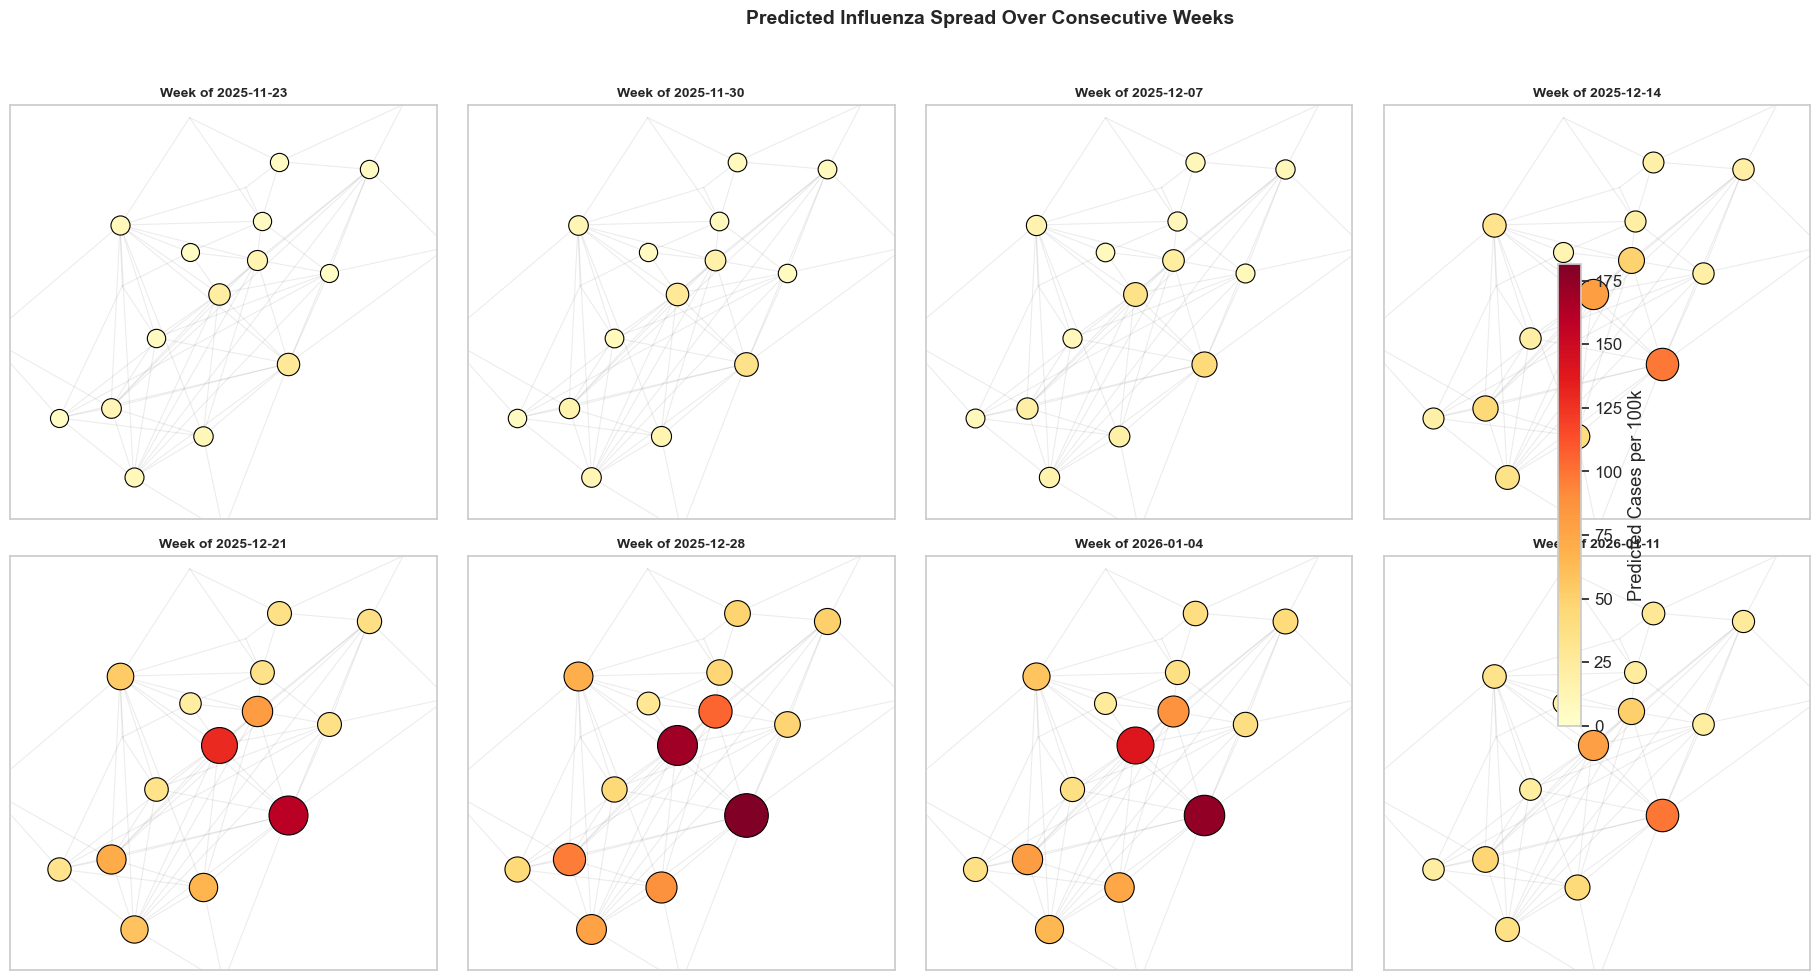

In [29]:
start = max(0, peak_idx - 4)
end = min(len(test_samples), start + 8)
selected = range(start, end)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()
vmax_global = targets_arr[start:end].max()
cmap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=0, vmax=vmax_global)

for plot_idx, t_idx in enumerate(selected):
    if plot_idx >= 8:
        break
    ax = axes_flat[plot_idx]
    data_slice = preds_arr[t_idx]

    for i in range(N_NODES):
        for j in range(i + 1, N_NODES):
            if A[i, j] > 0:
                n1, n2 = ALL_NODES[i], ALL_NODES[j]
                ax.plot([COORDS[n1][0], COORDS[n2][0]],
                        [COORDS[n1][1], COORDS[n2][1]],
                        '-', color='gray', alpha=0.15, linewidth=0.8)

    for i, n in enumerate(SHORT_NAMES):
        color = cmap(norm(data_slice[i]))
        size = 150 + max(0, data_slice[i]) * 4
        ax.scatter(*COORDS[n], s=size, c=[color], edgecolors='black', linewidth=0.8, zorder=5)

    actual_week = test_weeks_idx[t_idx]
    ax.set_title(f'Week of {pd.Timestamp(actual_week).strftime("%Y-%m-%d")}', fontsize=10, fontweight='bold')
    ax.set_xlim(-71.18, -70.99)
    ax.set_ylim(42.24, 42.40)
    ax.set_xticks([])
    ax.set_yticks([])

for i in range(len(selected), 8):
    axes_flat[i].axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes_flat, label='Predicted Cases per 100k', shrink=0.6, pad=0.02)
plt.suptitle('Predicted Influenza Spread Over Consecutive Weeks', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.92, 0.96])
plt.show()


## 8. Feature Importance (Gradient-Based)

We compute the mean absolute gradient of the loss w.r.t. input node features across the test set.


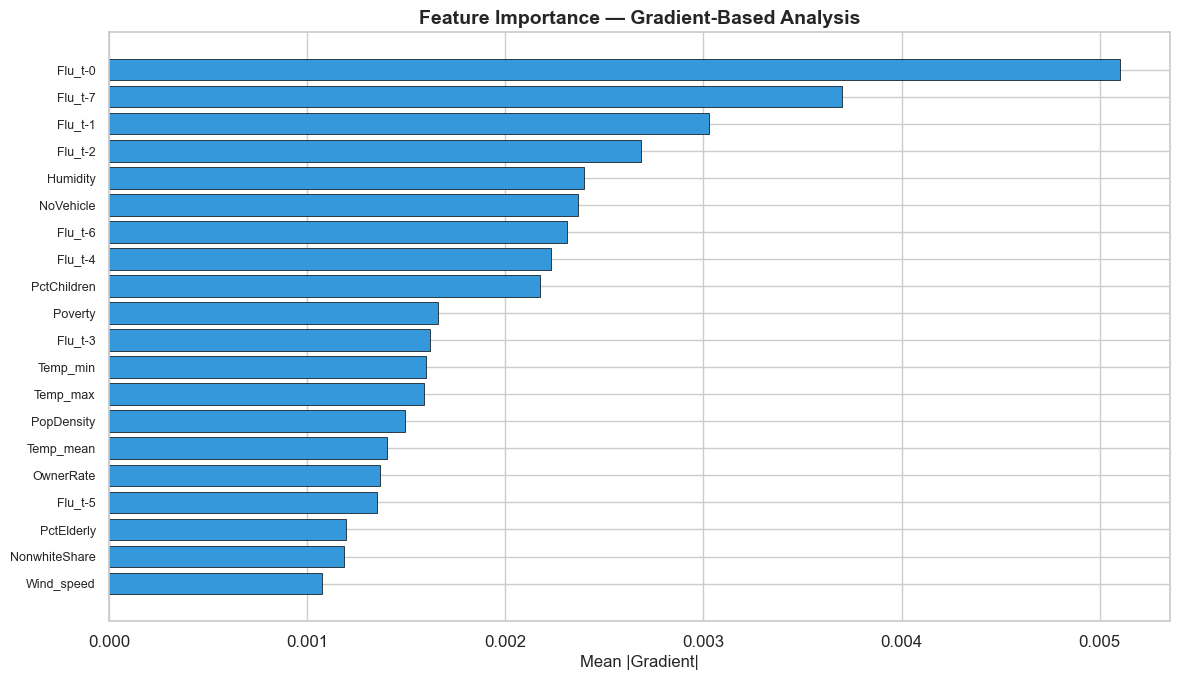

In [30]:
model.eval()
importance = torch.zeros(N_FEAT).to(device)
n_samples = 0

for X, g, y in test_samples:
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    X_t.requires_grad_(True)
    X_t.retain_grad()
    g_t = torch.tensor(g, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).to(device)

    pred = model(X_t, edge_index_dev, g_t, edge_weight_dev)
    loss = criterion(pred[:N_NEIGH, 0], y_t[:, 0])  # gradient on horizon-1
    loss.backward()

    if X_t.grad is not None:
        grad = X_t.grad[:N_NEIGH].abs().mean(dim=0)
        importance += grad
        n_samples += 1

importance = (importance / max(n_samples, 1)).cpu().detach().numpy()

# Feature names — built to match build_sample() exactly
feat_names = []
for lag in range(LOOKBACK):
    feat_names.append(f'Flu_t-{lag}')
    if USE_WASTEWATER:
        feat_names.append(f'Wastewater_t-{lag}')
if USE_WEATHER:
    feat_names += ['Temp_mean', 'Temp_max', 'Temp_min', 'Humidity', 'Precipitation', 'Wind_speed']
if USE_DEMOGRAPHICS:
    feat_names += ['PopDensity', 'Poverty', 'Transit', 'PctChildren',
                   'PctElderly', 'OwnerRate', 'NoVehicle', 'NonwhiteShare']

assert len(feat_names) == N_FEAT, f"feat_names ({len(feat_names)}) != N_FEAT ({N_FEAT})"

sorted_idx = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(12, 7))
top_k = min(len(feat_names), 20)
ax.barh(range(top_k), importance[sorted_idx[:top_k]][::-1],
        color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_k))
ax.set_yticklabels([feat_names[i] for i in sorted_idx[:top_k]][::-1], fontsize=9)
ax.set_xlabel('Mean |Gradient|', fontsize=12)
ax.set_title('Feature Importance — Gradient-Based Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Global Covariate Feature Importance

We can measure how sensitive the loss is to each global covariate by computing the mean absolute gradient with respect to the global input vector.

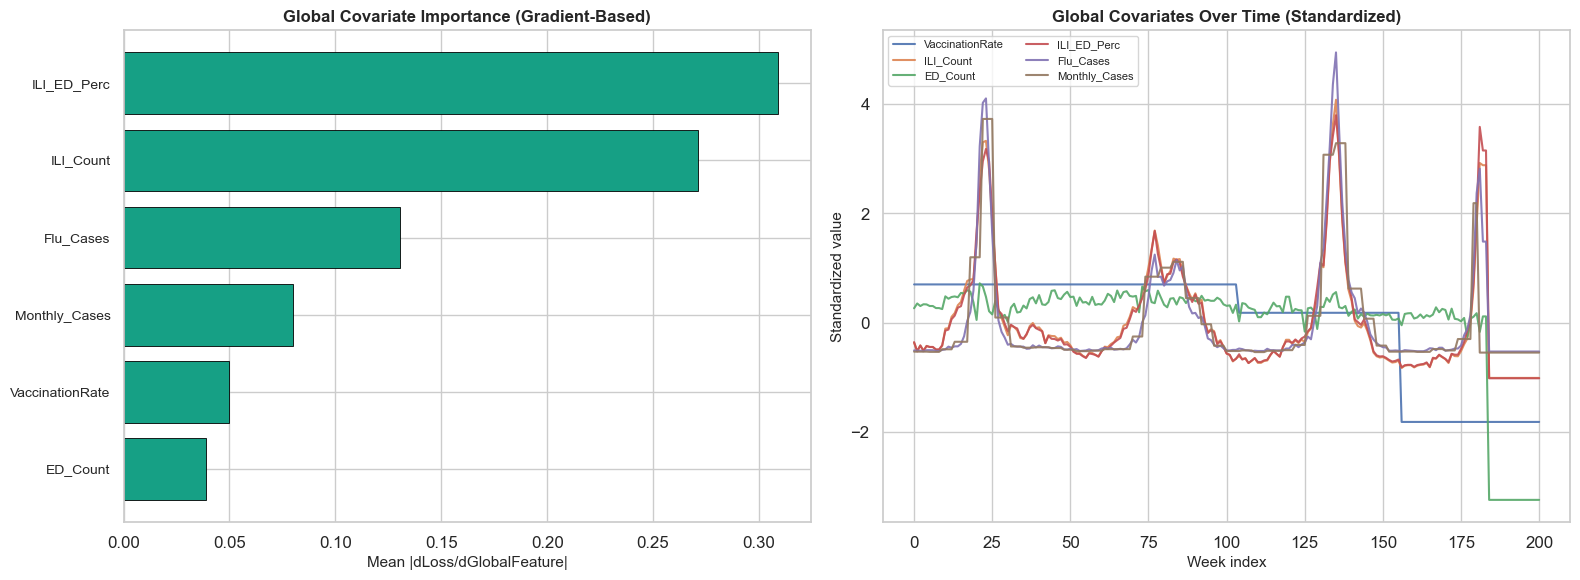

In [31]:
# -------------------------------------------------------
# Global covariates as features: gradient importance + trajectories
# -------------------------------------------------------
if N_GLOBAL == 0:
    print("No global covariates active (all USE_* global flags are False). Skipping.")
else:
    model.eval()
    g_importance = torch.zeros(N_GLOBAL).to(device)
    n_samples_g = 0

    for X, g, y in test_samples:
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        g_t = torch.tensor(g, dtype=torch.float32).to(device)
        g_t.requires_grad_(True)
        y_t = torch.tensor(y, dtype=torch.float32).to(device)

        model.zero_grad(set_to_none=True)
        pred = model(X_t, edge_index_dev, g_t, edge_weight_dev)
        loss = criterion(pred[:N_NEIGH, 0], y_t[:, 0])  # gradient on horizon-1
        loss.backward()

        if g_t.grad is not None:
            g_importance += g_t.grad.abs()
            n_samples_g += 1

    g_importance = (g_importance / max(n_samples_g, 1)).detach().cpu().numpy()

    # Build global names + matrix in same order as build_sample()
    global_names = []
    global_columns = []
    if USE_VACCINATION:   global_names.append('VaccinationRate'); global_columns.append(vacc_np)
    if USE_ILI_COUNT:     global_names.append('ILI_Count');       global_columns.append(ili_count_norm)
    if USE_ED_COUNT:      global_names.append('ED_Count');        global_columns.append(ed_count_norm)
    if USE_ILI_ED_PERC:   global_names.append('ILI_ED_Perc');     global_columns.append(ili_ed_perc_norm)
    if USE_FLU_CASES:     global_names.append('Flu_Cases');       global_columns.append(flu_cases_norm)
    if USE_MONTHLY_CASES: global_names.append('Monthly_Cases');   global_columns.append(mc_norm)

    assert len(global_names) == N_GLOBAL, f"global_names ({len(global_names)}) != N_GLOBAL ({N_GLOBAL})"
    global_matrix = np.column_stack(global_columns)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # (a) Gradient-based feature importance
    ax = axes[0]
    sorted_idx = np.argsort(g_importance)[::-1]
    ax.barh(range(N_GLOBAL), g_importance[sorted_idx][::-1], color='#16a085', edgecolor='black', linewidth=0.6)
    ax.set_yticks(range(N_GLOBAL))
    ax.set_yticklabels([global_names[i] for i in sorted_idx][::-1], fontsize=10)
    ax.set_xlabel('Mean |dLoss/dGlobalFeature|', fontsize=11)
    ax.set_title('Global Covariate Importance (Gradient-Based)', fontsize=12, fontweight='bold')

    # (b) Global covariate trajectories over time (standardized view)
    ax = axes[1]
    for i, name in enumerate(global_names):
        series = global_matrix[:, i]
        series_std = (series - series.mean()) / (series.std() + 1e-8)
        ax.plot(range(len(series_std)), series_std, label=name, linewidth=1.5, alpha=0.9)
    ax.set_xlabel('Week index', fontsize=11)
    ax.set_ylabel('Standardized value', fontsize=11)
    ax.set_title('Global Covariates Over Time (Standardized)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()


## 9. Summary

In [32]:
summary_df = pd.DataFrame({
    'Neighborhood': SHORT_NAMES,
    'Spearman_rho': [f'{c:.4f}' for c in corrs],
    'Lins_CCC': [f'{cv:.4f}' for cv in ccc_corrs],
    'MAE': [f'{np.mean(np.abs(preds_arr[:, i] - targets_arr[:, i])):.2f}' for i in range(N_NEIGH)],
    'RMSE': [f'{np.sqrt(np.mean((preds_arr[:, i] - targets_arr[:, i])**2)):.2f}' for i in range(N_NEIGH)],
    'Mean_Actual': [f'{targets_arr[:, i].mean():.2f}' for i in range(N_NEIGH)],
    'Mean_Predicted': [f'{preds_arr[:, i].mean():.2f}' for i in range(N_NEIGH)],
})

print("=" * 80)
print("MODEL PERFORMANCE SUMMARY (horizon-1)")
print("=" * 80)
print(f"\nOverall Test MAE:                          {mae:.2f} cases per 100k")
print(f"Overall Test RMSE:                         {rmse:.2f} cases per 100k")
print(f"Mean Spearman ρ (per-nbr, temporal):       {mean_spearman_temporal:.4f}")
print(f"Mean Lin's CCC (per-nbr, temporal):        {mean_ccc_temporal:.4f}")
print(f"Mean Spearman ρ (per-week, cross-nbr):     {mean_spearman_cross:.4f}")
print(f"Mean Lin's CCC (per-week, cross-nbr):      {mean_ccc_cross:.4f}")
print(f"95% CI coverage (MC-Dropout):              {ci_coverage * 100:.1f}%")
print(f"\nArchitecture: 2×GCNConv({N_FEAT}→64→32) + GlobalFusion(32+{N_GLOBAL}→32) + Linear(32→{N_HORIZONS})")
print(f"Graph: {N_NEIGH} neighborhoods + {N_BG} surrounding anchors = {N_NODES} nodes, geographic + correlation (weighted) edges")
print(f"Lookback: {LOOKBACK} weeks | Horizons: {HORIZONS}")
print(f"Device: {device}")
print()
print(summary_df.to_string(index=False))

MODEL PERFORMANCE SUMMARY (horizon-1)

Overall Test MAE:                          8.84 cases per 100k
Overall Test RMSE:                         12.98 cases per 100k
Mean Spearman ρ (per-nbr, temporal):       0.2898
Mean Lin's CCC (per-nbr, temporal):        0.8165
Mean Spearman ρ (per-week, cross-nbr):     0.6904
Mean Lin's CCC (per-week, cross-nbr):      0.5137
95% CI coverage (MC-Dropout):              48.1%

Architecture: 2×GCNConv(22→64→32) + GlobalFusion(32+6→32) + Linear(32→2)
Graph: 14 neighborhoods + 7 surrounding anchors = 21 nodes, geographic + correlation (weighted) edges
Lookback: 8 weeks | Horizons: [1, 2]
Device: cpu

Neighborhood Spearman_rho Lins_CCC   MAE  RMSE Mean_Actual Mean_Predicted
     Allston       0.2701   0.8640  7.68  9.42       19.32          13.08
    BackBay+       0.2896   0.7483  6.72  8.37       12.88           7.92
    Charles.       0.2705   0.7570  6.29  9.70       11.29           7.85
   Dorchest.       0.3446   0.8450 22.23 27.16       49.93     

### Save Model Checkpoint

In [33]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'edge_index': edge_index,
    'edge_weight': edge_weight,
    'flu_means': flu_means,
    'flu_stds': flu_stds,
    'neighborhoods': NEIGHBORHOODS,
    'n_feat': N_FEAT,
    'n_global': N_GLOBAL,
}
torch.save(checkpoint, 'influenza_gnn_v2_corrweighted_checkpoint.pt')
print("Model checkpoint saved to influenza_gnn_v2_corrweighted_checkpoint.pt")


Model checkpoint saved to influenza_gnn_v2_corrweighted_checkpoint.pt


In [34]:
## Carbon Tracking

emissions = tracker.stop()

# Constants for equivalencies
CAR_EMISSION_FACTOR = 0.12        # kgCO2 per km
TV_DAILY_WH = 138                 # Wh per day
TV_EMISSION_FACTOR = 0.084        # kgCO2 per kWh (implied by source)
US_WEEKLY_KG = (13.3 * 1000) / 52  # kg CO2 per week for avg US citizen

energy_kwh = tracker.final_emissions_data.energy_consumed

print("\nCarbon Emissions Summary:")
print(f"  Total CO₂ emitted:     {emissions:.7f} kg")
print(f"  Total energy consumed: {energy_kwh:.7f} kWh")
print(f"  Total cost of energy:  ${tracker.final_emissions_data.energy_consumed*0.269141194:.7f} USD")
print(f"    CPU energy:          {tracker.final_emissions_data.cpu_energy:.7f} kWh")
print(f"    RAM energy:          {tracker.final_emissions_data.ram_energy:.7f} kWh")
print(f"    GPU energy:          {tracker.final_emissions_data.gpu_energy:.7f} kWh")
print(f"  Duration:              {tracker.final_emissions_data.duration:.2f} s")

print("\nEquivalency Estimates:")
print(f"  🚗 Car distance:       {emissions / CAR_EMISSION_FACTOR:.4f} km driven")
print(f"  📺 TV usage:           {(energy_kwh / (TV_DAILY_WH / 1000)):.4f} days of TV")
print(f"  🧍 US citizen:         {(emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")


Carbon Emissions Summary:
  Total CO₂ emitted:     0.0000649 kg
  Total energy consumed: 0.0001758 kWh
  Total cost of energy:  $0.0000473 USD
    CPU energy:          0.0001540 kWh
    RAM energy:          0.0000217 kWh
    GPU energy:          0.0000000 kWh
  Duration:              13.05 s

Equivalency Estimates:
  🚗 Car distance:       0.0005 km driven
  📺 TV usage:           0.0013 days of TV
  🧍 US citizen:         0.000025% of weekly per-capita emissions


## 10. Next Steps

**Current model uses geographic adjacency only.** Future improvements:

1. **Experiment with architectures**: GAT (attention over neighbors), GraphSAGE, or temporal attention layers
2. **Hyperparameter search**: hidden dimensions, learning rate, lookback window, dropout rate
3. **Baseline comparisons**: ARIMA per-neighborhood, LSTM without graph, naive persistence
4. **GNNExplainer**: identify which edges and features drive each neighborhood's prediction
5. **Real-time inference**: wrap in a Flask/FastAPI endpoint for BPHC dashboard integration
